# None/Linear/Neural baseline

[none] Episode  100 | Train utility (last100 mean) = -0.119604 | Baseline loss = 0.000000 | Eval mean utility = -0.119137 | Eval mean wealth = 1.5235
[none] Episode  200 | Train utility (last100 mean) = -0.120234 | Baseline loss = 0.000000 | Eval mean utility = -0.115754 | Eval mean wealth = 1.5614
[none] Episode  300 | Train utility (last100 mean) = -0.118029 | Baseline loss = 0.000000 | Eval mean utility = -0.116413 | Eval mean wealth = 1.5539
[none] Episode  400 | Train utility (last100 mean) = -0.113303 | Baseline loss = 0.000000 | Eval mean utility = -0.121690 | Eval mean wealth = 1.4907
[none] Episode  500 | Train utility (last100 mean) = -0.121435 | Baseline loss = 0.000000 | Eval mean utility = -0.115024 | Eval mean wealth = 1.5680
[none] Episode  600 | Train utility (last100 mean) = -0.102445 | Baseline loss = 0.000000 | Eval mean utility = -0.111777 | Eval mean wealth = 1.6141
[none] Episode  700 | Train utility (last100 mean) = -0.118383 | Baseline loss = 0.000000 | Eval mea

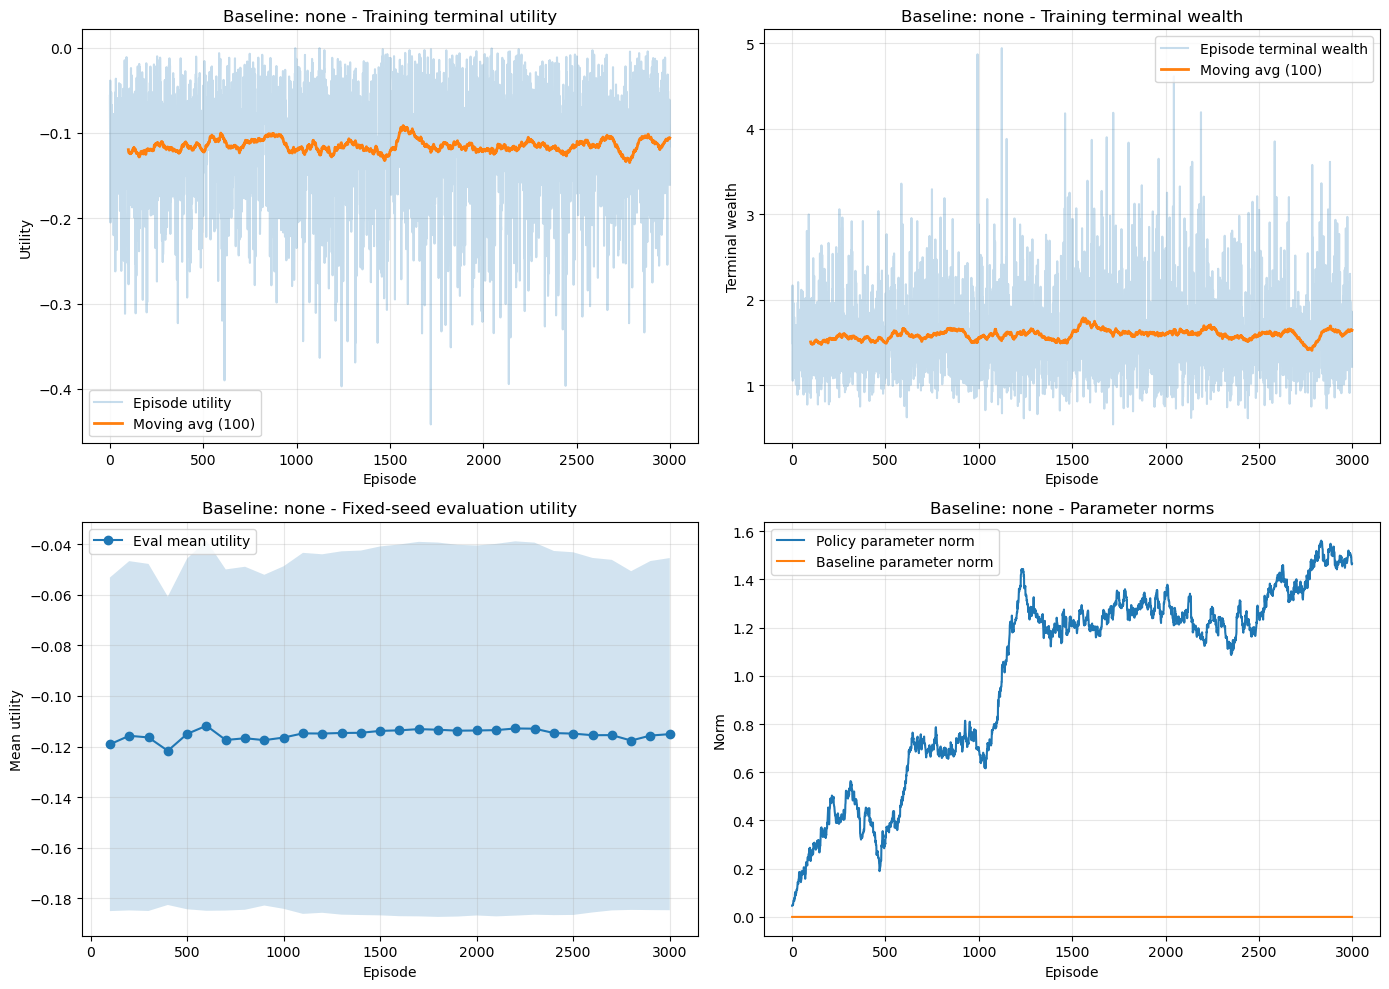

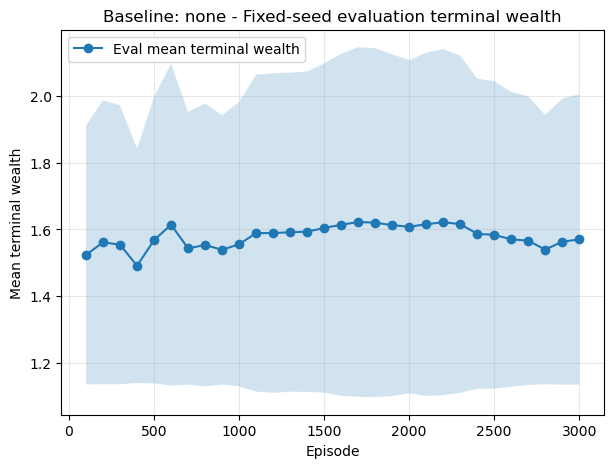



[linear] Episode  100 | Train utility (last100 mean) = -0.119567 | Baseline loss = 0.015167 | Eval mean utility = -0.119819 | Eval mean wealth = 1.5167
[linear] Episode  200 | Train utility (last100 mean) = -0.120943 | Baseline loss = 0.012440 | Eval mean utility = -0.117030 | Eval mean wealth = 1.5461
[linear] Episode  300 | Train utility (last100 mean) = -0.119254 | Baseline loss = 0.008996 | Eval mean utility = -0.117745 | Eval mean wealth = 1.5383
[linear] Episode  400 | Train utility (last100 mean) = -0.112007 | Baseline loss = 0.006548 | Eval mean utility = -0.119277 | Eval mean wealth = 1.5211
[linear] Episode  500 | Train utility (last100 mean) = -0.118657 | Baseline loss = 0.006570 | Eval mean utility = -0.115652 | Eval mean wealth = 1.5691
[linear] Episode  600 | Train utility (last100 mean) = -0.103307 | Baseline loss = 0.004902 | Eval mean utility = -0.113648 | Eval mean wealth = 1.6051
[linear] Episode  700 | Train utility (last100 mean) = -0.117448 | Baseline loss = 0.0

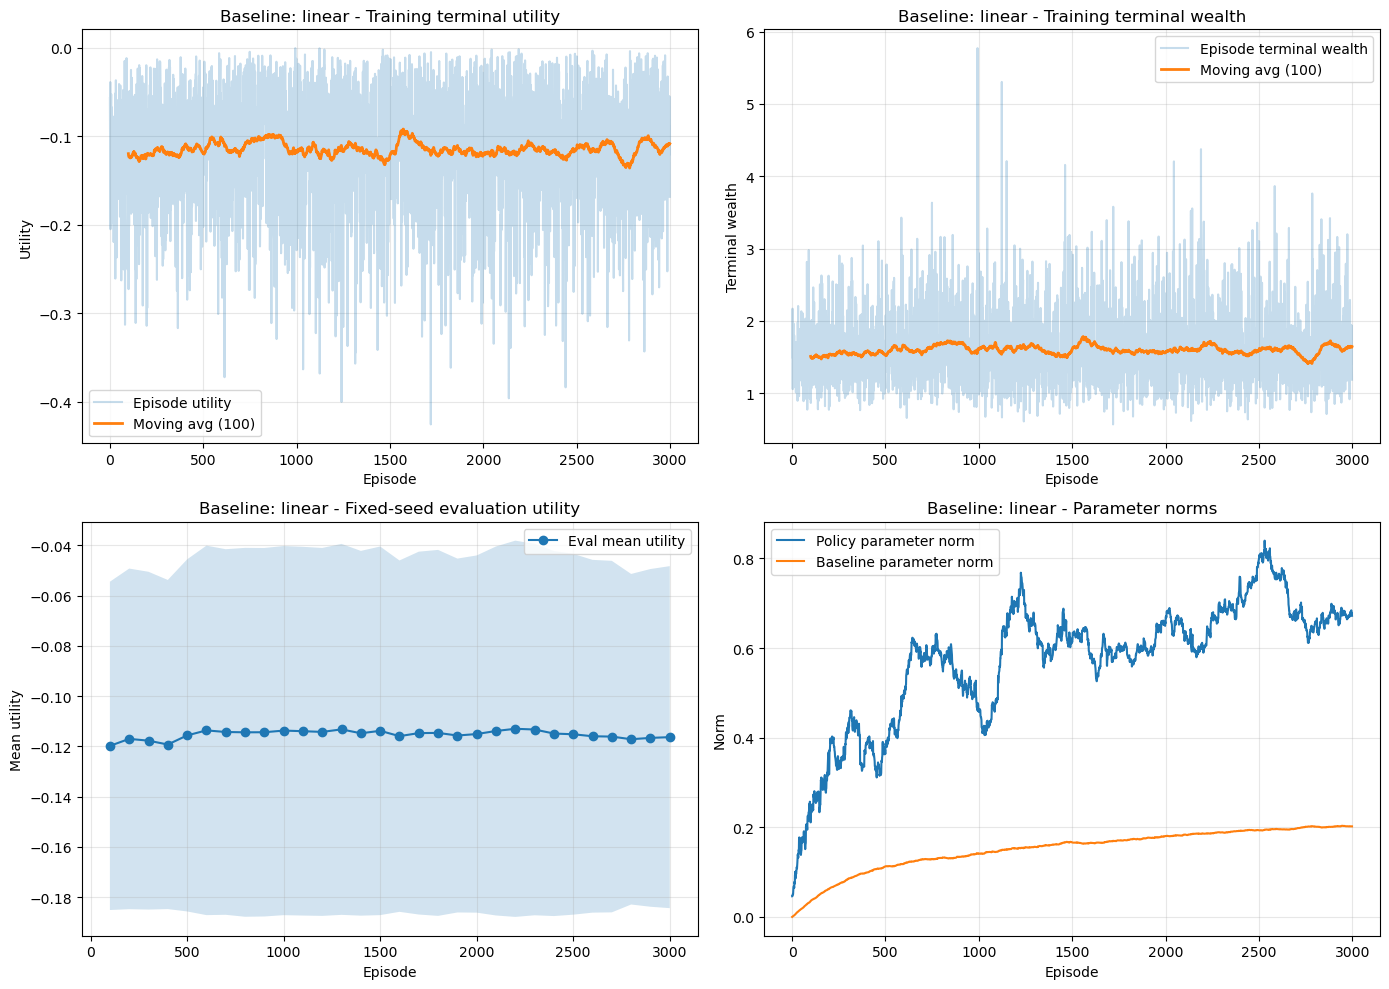

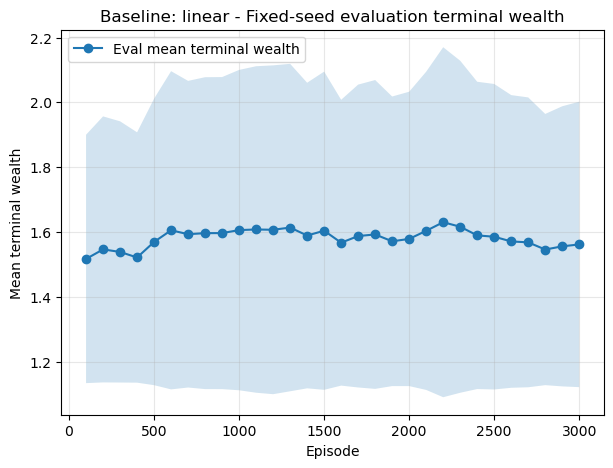



[neural] Episode  100 | Train utility (last100 mean) = -0.117209 | Baseline loss = 0.002392 | Eval mean utility = -0.124528 | Eval mean wealth = 1.4547
[neural] Episode  200 | Train utility (last100 mean) = -0.127083 | Baseline loss = 0.002167 | Eval mean utility = -0.125488 | Eval mean wealth = 1.4495
[neural] Episode  300 | Train utility (last100 mean) = -0.126681 | Baseline loss = 0.001660 | Eval mean utility = -0.124249 | Eval mean wealth = 1.4593
[neural] Episode  400 | Train utility (last100 mean) = -0.118028 | Baseline loss = 0.001612 | Eval mean utility = -0.125209 | Eval mean wealth = 1.4485
[neural] Episode  500 | Train utility (last100 mean) = -0.127722 | Baseline loss = 0.001479 | Eval mean utility = -0.124331 | Eval mean wealth = 1.4558
[neural] Episode  600 | Train utility (last100 mean) = -0.116580 | Baseline loss = 0.001410 | Eval mean utility = -0.123114 | Eval mean wealth = 1.4732
[neural] Episode  700 | Train utility (last100 mean) = -0.125291 | Baseline loss = 0.0

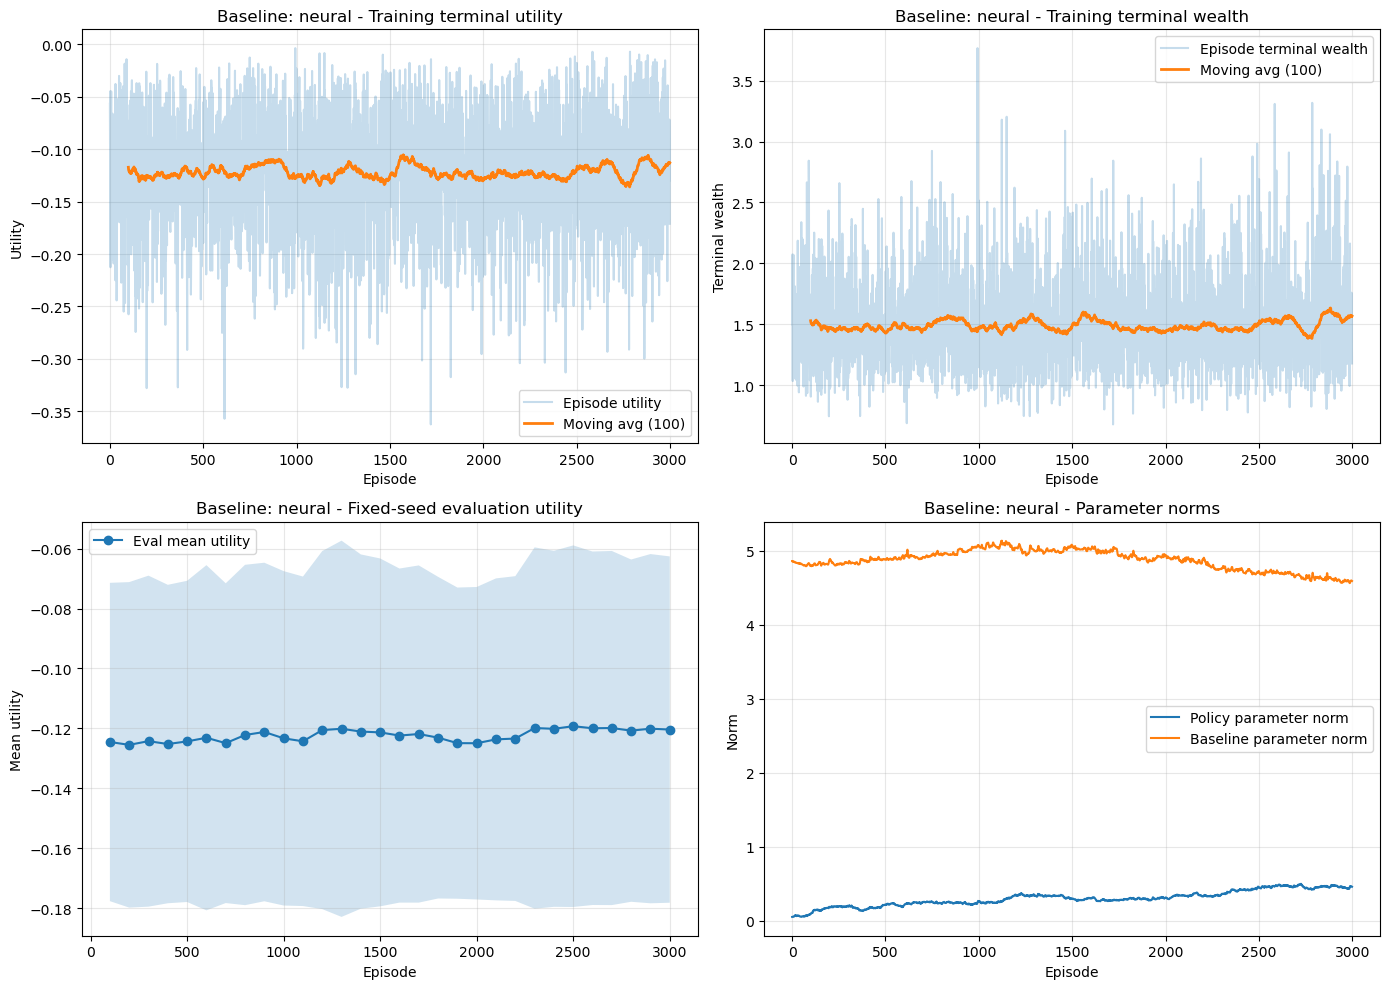

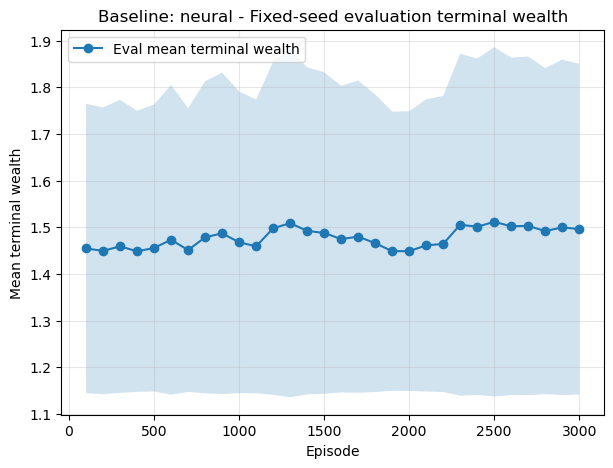

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


def cara_utility(w, risk_aversion):
    return -np.exp(-risk_aversion * w)


def project_to_simplex(v):
    v = np.asarray(v, dtype=float)
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    w = np.maximum(v - theta, 0.0)
    return w


def enforce_turnover_constraint(old_w, new_w, max_turnover=0.10):
    d = new_w - old_w
    l1 = np.sum(np.abs(d))
    if l1 <= max_turnover:
        return new_w
    alpha = max_turnover / (l1 + 1e-12)
    return old_w + alpha * d


def valid_portfolio_update(old_w, raw_delta, max_turnover=0.10):
    d = raw_delta - np.mean(raw_delta)

    l1 = np.sum(np.abs(d))
    if l1 > max_turnover:
        d = d * (max_turnover / (l1 + 1e-12))

    candidate = old_w + d
    candidate = project_to_simplex(candidate)
    candidate = enforce_turnover_constraint(old_w, candidate, max_turnover=max_turnover)
    candidate = project_to_simplex(candidate)

    return candidate


class AssetAllocationEnv:
    def __init__(self, means, variances, cash_rate, horizon, init_weights, init_wealth=1.0,
                 risk_aversion=1.0, seed=None):
        self.means = np.array(means, dtype=float)
        self.variances = np.array(variances, dtype=float)
        self.stds = np.sqrt(self.variances)
        self.n_risky = len(means)
        self.n_assets_total = self.n_risky + 1
        self.r = cash_rate
        self.T = horizon
        self.init_weights = np.array(init_weights, dtype=float)
        self.init_wealth = init_wealth
        self.risk_aversion = risk_aversion
        self.rng = np.random.default_rng(seed)

        assert len(self.init_weights) == self.n_assets_total
        assert np.isclose(np.sum(self.init_weights), 1.0)
        assert np.all(self.init_weights >= 0)
        assert self.T < 10
        assert self.n_risky < 5

        self.reset()

    def reset(self):
        self.t = 0
        self.wealth = self.init_wealth
        self.weights = self.init_weights.copy()
        return self._state()

    def _state(self):
        return np.concatenate(([self.t / self.T, np.log(max(self.wealth, 1e-8))], self.weights))

    def step(self, new_weights):
        new_weights = np.asarray(new_weights, dtype=float)

        risky_returns = self.rng.normal(self.means, self.stds)
        gross_returns = np.concatenate(([1.0 + self.r], 1.0 + risky_returns))

        portfolio_gross = np.dot(new_weights, gross_returns)
        next_wealth = self.wealth * portfolio_gross

        next_values = self.wealth * new_weights * gross_returns
        next_weights = next_values / np.sum(next_values)

        self.wealth = next_wealth
        self.weights = next_weights
        self.t += 1

        done = (self.t == self.T)
        reward = 0.0
        if done:
            reward = cara_utility(self.wealth, self.risk_aversion)

        return self._state(), reward, done, {
            "wealth": self.wealth,
            "weights": self.weights.copy(),
            "risky_returns": risky_returns,
            "gross_returns": gross_returns
        }


class LinearGaussianPolicy:
    def __init__(self, state_dim, action_dim, init_std=0.05, seed=None):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.rng = np.random.default_rng(seed)

        self.W = 0.01 * self.rng.normal(size=(action_dim, state_dim))
        self.b = np.zeros(action_dim)
        self.log_std = np.log(init_std) * np.ones(action_dim)

    def forward(self, state):
        mu = self.W @ state + self.b
        std = np.exp(self.log_std)
        return mu, std

    def sample_action(self, state):
        mu, std = self.forward(state)
        raw_action = mu + std * self.rng.normal(size=self.action_dim)
        z = (raw_action - mu) / std
        log_prob = -0.5 * np.sum(z**2 + 2*np.log(std) + np.log(2*np.pi))
        return raw_action, log_prob, mu, std

    def grad_log_prob(self, state, raw_action):
        mu, std = self.forward(state)
        diff = (raw_action - mu) / (std**2)
        grad_W = np.outer(diff, state)
        grad_b = diff
        return grad_W, grad_b

    def param_norm(self):
        return np.sqrt(np.sum(self.W**2) + np.sum(self.b**2))


# =========================
# Unified baseline classes
# =========================

class NoBaseline:
    def predict(self, state):
        return 0.0

    def fit_batch(self, states, returns, **kwargs):
        return 0.0

    def param_norm(self):
        return 0.0

    @property
    def name(self):
        return "none"


class LinearValueBaseline:
    def __init__(self, state_dim, seed=None):
        self.rng = np.random.default_rng(seed)
        self.w = np.zeros(state_dim)

    def predict(self, state):
        return float(np.dot(self.w, state))

    def fit_batch(self, states, returns, lr=1e-2, epochs=20, **kwargs):
        states = np.array(states)
        returns = np.array(returns)
        last_loss = 0.0
        for _ in range(epochs):
            preds = states @ self.w
            err = preds - returns
            grad = states.T @ err / len(states)
            self.w -= lr * grad
            last_loss = np.mean(err ** 2)
        return float(last_loss)

    def param_norm(self):
        return np.linalg.norm(self.w)

    @property
    def name(self):
        return "linear"


class NeuralValueBaseline(nn.Module):
    def __init__(self, state_dim, hidden_dim=32, lr=1e-3, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, states):
        return self.net(states).squeeze(-1)

    def predict(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            value = self.forward(state_t).item()
        return float(value)

    def fit_batch(self, states, returns, epochs=20, **kwargs):
        states_t = torch.tensor(np.array(states), dtype=torch.float32)
        returns_t = torch.tensor(np.array(returns), dtype=torch.float32)

        last_loss = 0.0
        for _ in range(epochs):
            preds = self.forward(states_t)
            loss = self.loss_fn(preds, returns_t)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            last_loss = loss.item()
        return float(last_loss)

    def param_norm(self):
        total = 0.0
        with torch.no_grad():
            for p in self.parameters():
                total += torch.sum(p ** 2).item()
        return float(np.sqrt(total))

    @property
    def name(self):
        return "neural"


def make_baseline(baseline_type, state_dim, baseline_lr=1e-2, hidden_dim=32, seed=None):
    baseline_type = baseline_type.lower()

    if baseline_type == "none":
        return NoBaseline()
    elif baseline_type == "linear":
        return LinearValueBaseline(state_dim=state_dim, seed=seed)
    elif baseline_type in ["neural", "nn", "mlp"]:
        return NeuralValueBaseline(
            state_dim=state_dim,
            hidden_dim=hidden_dim,
            lr=baseline_lr,
            seed=seed
        )
    else:
        raise ValueError(f"Unknown baseline_type: {baseline_type}")


def run_episode(env, policy, max_turnover=0.10):
    states = []
    raw_actions = []
    rewards = []
    infos = []

    state = env.reset()
    done = False

    while not done:
        raw_action, log_prob, mu, std = policy.sample_action(state)

        old_w = env.weights.copy()
        new_w = valid_portfolio_update(old_w, raw_action, max_turnover=max_turnover)

        next_state, reward, done, info = env.step(new_w)

        states.append(state)
        raw_actions.append(raw_action)
        rewards.append(reward)
        infos.append({
            "old_w": old_w,
            "new_w": new_w,
            "mu": mu,
            "std": std,
            **info
        })

        state = next_state

    G = sum(rewards)
    terminal_wealth = infos[-1]["wealth"]
    return states, raw_actions, rewards, infos, G, terminal_wealth


def evaluate_policy(env_config, policy, n_eval=200, max_turnover=0.10, seed=999):
    utilities = []
    wealths = []

    for i in range(n_eval):
        env = AssetAllocationEnv(
            means=env_config["means"],
            variances=env_config["variances"],
            cash_rate=env_config["cash_rate"],
            horizon=env_config["horizon"],
            init_weights=env_config["init_weights"],
            init_wealth=env_config["init_wealth"],
            risk_aversion=env_config["risk_aversion"],
            seed=seed + i
        )

        state = env.reset()
        done = False

        while not done:
            mu, std = policy.forward(state)
            action_w = valid_portfolio_update(env.weights.copy(), mu, max_turnover=max_turnover)
            state, reward, done, info = env.step(action_w)

        utilities.append(reward)
        wealths.append(info["wealth"])

    return np.mean(utilities), np.std(utilities), np.mean(wealths), np.std(wealths)


def moving_average(x, window=100):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode='valid')


def train_policy_gradient(env,
                          episodes=5000,
                          policy_lr=5e-3,
                          baseline_type="linear",
                          baseline_lr=1e-2,
                          baseline_epochs=5,
                          baseline_hidden_dim=32,
                          max_turnover=0.10,
                          eval_every=100,
                          eval_paths=200,
                          seed=None):
    state_dim = 2 + env.n_assets_total
    action_dim = env.n_assets_total

    policy = LinearGaussianPolicy(state_dim, action_dim, init_std=0.05, seed=seed)
    baseline = make_baseline(
        baseline_type=baseline_type,
        state_dim=state_dim,
        baseline_lr=baseline_lr,
        hidden_dim=baseline_hidden_dim,
        seed=seed
    )

    env_config = {
        "means": env.means.copy(),
        "variances": env.variances.copy(),
        "cash_rate": env.r,
        "horizon": env.T,
        "init_weights": env.init_weights.copy(),
        "init_wealth": env.init_wealth,
        "risk_aversion": env.risk_aversion
    }

    history = {
        "baseline_type": baseline_type,
        "train_utility": [],
        "train_terminal_wealth": [],
        "policy_norm": [],
        "baseline_norm": [],
        "baseline_loss": [],
        "eval_episode": [],
        "eval_mean_utility": [],
        "eval_std_utility": [],
        "eval_mean_wealth": [],
        "eval_std_wealth": []
    }

    for ep in range(episodes):
        states, raw_actions, rewards, infos, G, terminal_wealth = run_episode(
            env, policy, max_turnover=max_turnover
        )

        returns = [G for _ in states]
        baseline_loss = baseline.fit_batch(
            states,
            returns,
            lr=baseline_lr,
            epochs=baseline_epochs
        )

        grad_W_sum = np.zeros_like(policy.W)
        grad_b_sum = np.zeros_like(policy.b)

        for s, a in zip(states, raw_actions):
            advantage = G - baseline.predict(s)
            grad_W, grad_b = policy.grad_log_prob(s, a)
            grad_W_sum += advantage * grad_W
            grad_b_sum += advantage * grad_b

        grad_W_sum /= len(states)
        grad_b_sum /= len(states)

        policy.W += policy_lr * grad_W_sum
        policy.b += policy_lr * grad_b_sum

        history["train_utility"].append(G)
        history["train_terminal_wealth"].append(terminal_wealth)
        history["policy_norm"].append(policy.param_norm())
        history["baseline_norm"].append(baseline.param_norm())
        history["baseline_loss"].append(baseline_loss)

        if (ep + 1) % eval_every == 0:
            mean_u, std_u, mean_w, std_w = evaluate_policy(
                env_config,
                policy,
                n_eval=eval_paths,
                max_turnover=max_turnover,
                seed=999
            )
            history["eval_episode"].append(ep + 1)
            history["eval_mean_utility"].append(mean_u)
            history["eval_std_utility"].append(std_u)
            history["eval_mean_wealth"].append(mean_w)
            history["eval_std_wealth"].append(std_w)

            print(
                f"[{baseline_type}] Episode {ep+1:4d} | "
                f"Train utility (last100 mean) = {np.mean(history['train_utility'][-100:]):.6f} | "
                f"Baseline loss = {np.mean(history['baseline_loss'][-100:]):.6f} | "
                f"Eval mean utility = {mean_u:.6f} | "
                f"Eval mean wealth = {mean_w:.4f}"
            )

    return policy, baseline, history


def plot_training_history(history, ma_window=100):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    title_prefix = f"Critic: {history.get('baseline_type', 'unknown')}"

    axes[0, 0].plot(history["train_utility"], alpha=0.25, label="Episode utility")
    ma_u = moving_average(history["train_utility"], ma_window)
    if len(ma_u) > 0:
        x_ma = np.arange(len(ma_u)) + (ma_window - 1 if len(history["train_utility"]) >= ma_window else 0)
        axes[0, 0].plot(x_ma, ma_u, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 0].set_title(f"{title_prefix} - Training terminal utility")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Utility")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history["train_terminal_wealth"], alpha=0.25, label="Episode terminal wealth")
    ma_w = moving_average(history["train_terminal_wealth"], ma_window)
    if len(ma_w) > 0:
        x_ma = np.arange(len(ma_w)) + (ma_window - 1 if len(history["train_terminal_wealth"]) >= ma_window else 0)
        axes[0, 1].plot(x_ma, ma_w, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 1].set_title(f"{title_prefix} - Training terminal wealth")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Terminal wealth")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    eval_ep = np.array(history["eval_episode"])
    eval_u = np.array(history["eval_mean_utility"])
    eval_u_std = np.array(history["eval_std_utility"])
    if len(eval_ep) > 0:
        axes[1, 0].plot(eval_ep, eval_u, marker='o', label="Eval mean utility")
        axes[1, 0].fill_between(eval_ep, eval_u - eval_u_std, eval_u + eval_u_std, alpha=0.2)
    axes[1, 0].set_title(f"{title_prefix} - Fixed-seed evaluation utility")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Mean utility")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(history["policy_norm"], label="Policy parameter norm")
    axes[1, 1].plot(history["baseline_norm"], label="Critic parameter norm")
    axes[1, 1].set_title(f"{title_prefix} - Parameter norms")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Norm")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_eval_wealth(history):
    plt.figure(figsize=(7, 5))
    eval_ep = np.array(history["eval_episode"])
    eval_w = np.array(history["eval_mean_wealth"])
    eval_w_std = np.array(history["eval_std_wealth"])
    if len(eval_ep) > 0:
        plt.plot(eval_ep, eval_w, marker='o', label="Eval mean terminal wealth")
        plt.fill_between(eval_ep, eval_w - eval_w_std, eval_w + eval_w_std, alpha=0.2)
    plt.title(f"Critic: {history.get('baseline_type', 'unknown')} - Fixed-seed evaluation terminal wealth")
    plt.xlabel("Episode")
    plt.ylabel("Mean terminal wealth")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    means = [0.08, 0.12, 0.05]
    variances = [0.04, 0.09, 0.02]
    cash_rate = 0.03
    horizon = 6
    init_weights = [0.25, 0.25, 0.30, 0.20]   # cash + 3 risky assets
    risk_aversion = 1.5
    
    for baseline_type in ["none", "linear", "neural"]:
        env = AssetAllocationEnv(
            means=means,
            variances=variances,
            cash_rate=cash_rate,
            horizon=horizon,
            init_weights=init_weights,
            init_wealth=1.0,
            risk_aversion=risk_aversion,
            seed=123
        )

        # baseline_type 可选: "none", "linear", "neural"
        policy, baseline, history = train_policy_gradient(
            env,
            episodes=3000,
            policy_lr=0.01,
            baseline_type=baseline_type,
            baseline_lr=1e-3,        # neural 时建议小一点；linear 时也能用
            baseline_epochs=5,
            baseline_hidden_dim=32,
            max_turnover=0.10,
            eval_every=100,
            eval_paths=200,
            seed=123
        )
        print("=" * 80)
        print("\n")
        print(f"Finished training with critic: {baseline_type}")
        plot_training_history(history, ma_window=100)
        plot_eval_wealth(history)
        print("\n")

# actor-critic

[none] Episode  100 | Train utility (last100 mean) = -0.120029 | Critic loss = 0.002970 | Eval mean utility = -0.122455 | Eval mean wealth = 1.4804
[none] Episode  200 | Train utility (last100 mean) = -0.121960 | Critic loss = 0.003270 | Eval mean utility = -0.116914 | Eval mean wealth = 1.5342
[none] Episode  300 | Train utility (last100 mean) = -0.120955 | Critic loss = 0.002965 | Eval mean utility = -0.119219 | Eval mean wealth = 1.5094
[none] Episode  400 | Train utility (last100 mean) = -0.116974 | Critic loss = 0.002783 | Eval mean utility = -0.121760 | Eval mean wealth = 1.4858
[none] Episode  500 | Train utility (last100 mean) = -0.127581 | Critic loss = 0.003211 | Eval mean utility = -0.120408 | Eval mean wealth = 1.5027
[none] Episode  600 | Train utility (last100 mean) = -0.114000 | Critic loss = 0.002705 | Eval mean utility = -0.119670 | Eval mean wealth = 1.5076
[none] Episode  700 | Train utility (last100 mean) = -0.128416 | Critic loss = 0.003326 | Eval mean utility = -0

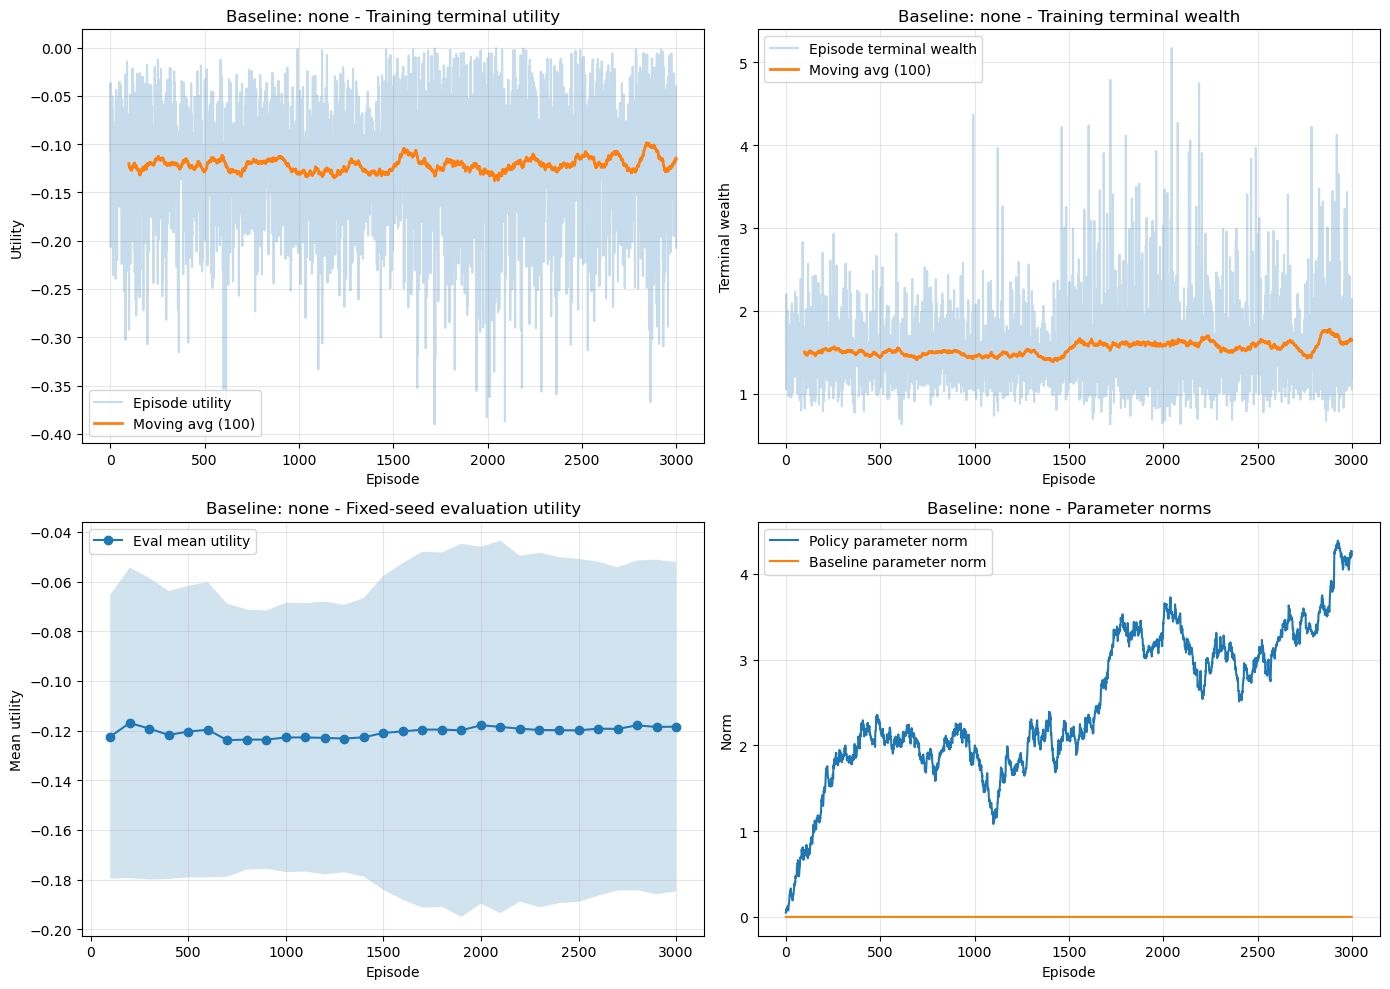

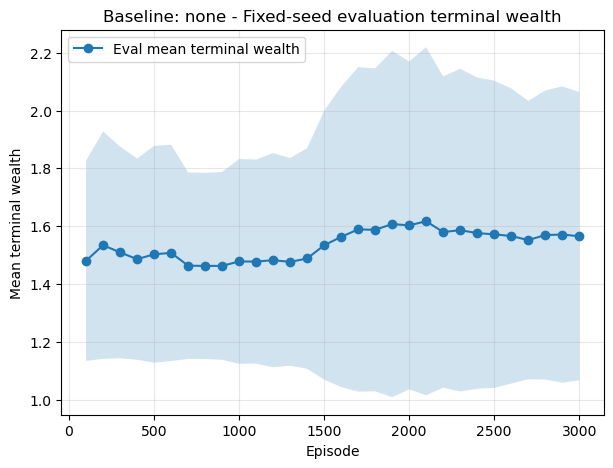



[linear] Episode  100 | Train utility (last100 mean) = -0.120093 | Critic loss = 0.002741 | Eval mean utility = -0.122415 | Eval mean wealth = 1.4806
[linear] Episode  200 | Train utility (last100 mean) = -0.121835 | Critic loss = 0.002620 | Eval mean utility = -0.116677 | Eval mean wealth = 1.5368
[linear] Episode  300 | Train utility (last100 mean) = -0.120798 | Critic loss = 0.001962 | Eval mean utility = -0.118878 | Eval mean wealth = 1.5126
[linear] Episode  400 | Train utility (last100 mean) = -0.116419 | Critic loss = 0.001552 | Eval mean utility = -0.121803 | Eval mean wealth = 1.4855
[linear] Episode  500 | Train utility (last100 mean) = -0.126974 | Critic loss = 0.001576 | Eval mean utility = -0.119944 | Eval mean wealth = 1.5045
[linear] Episode  600 | Train utility (last100 mean) = -0.113844 | Critic loss = 0.001141 | Eval mean utility = -0.118785 | Eval mean wealth = 1.5157
[linear] Episode  700 | Train utility (last100 mean) = -0.125393 | Critic loss = 0.001298 | Eval m

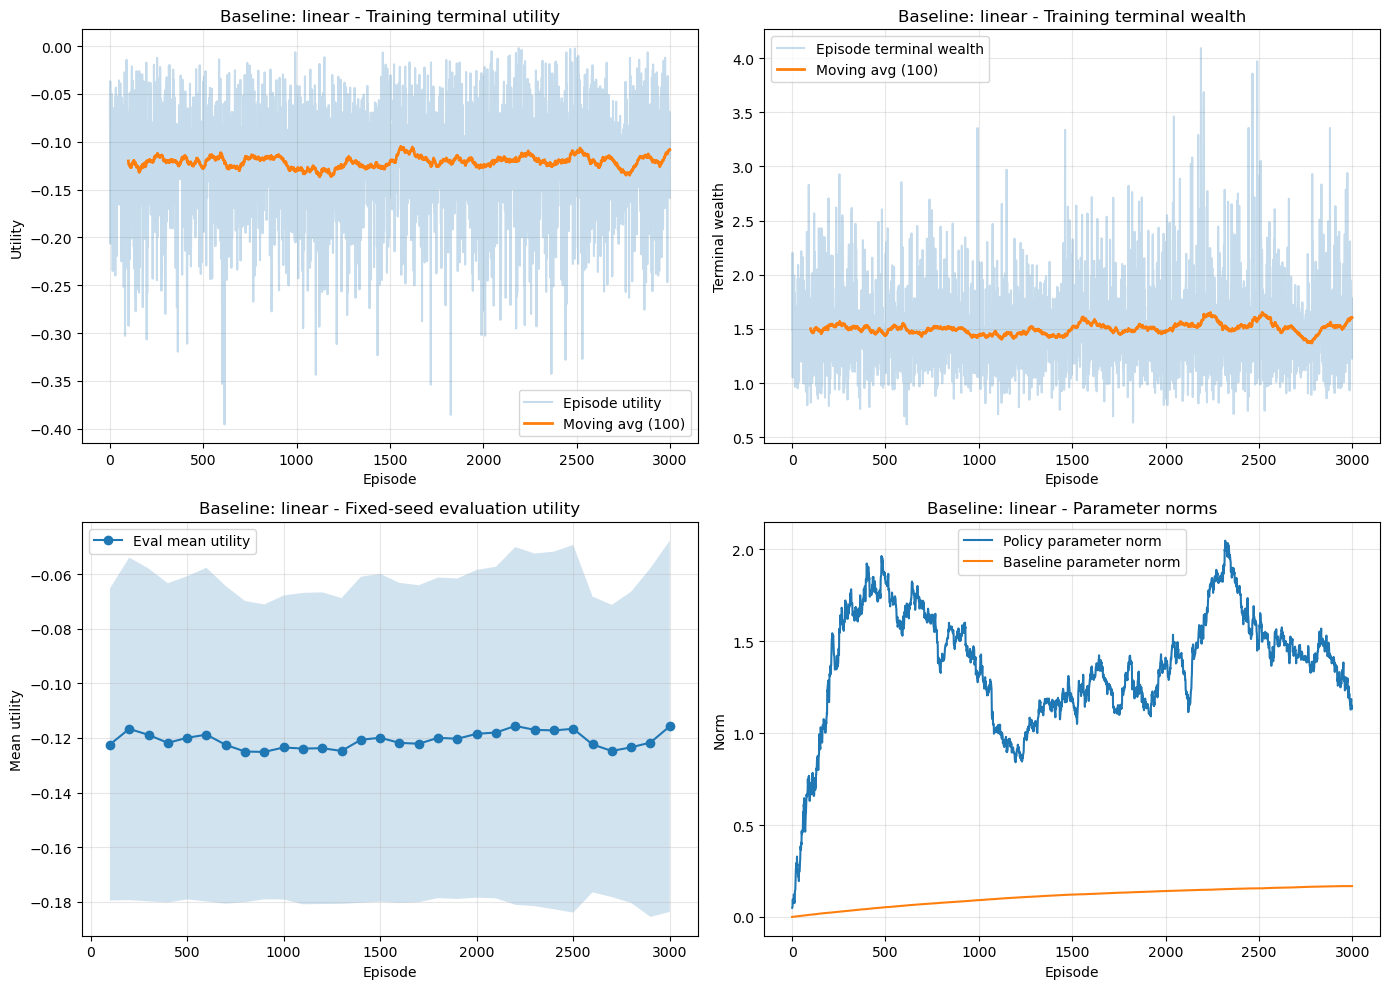

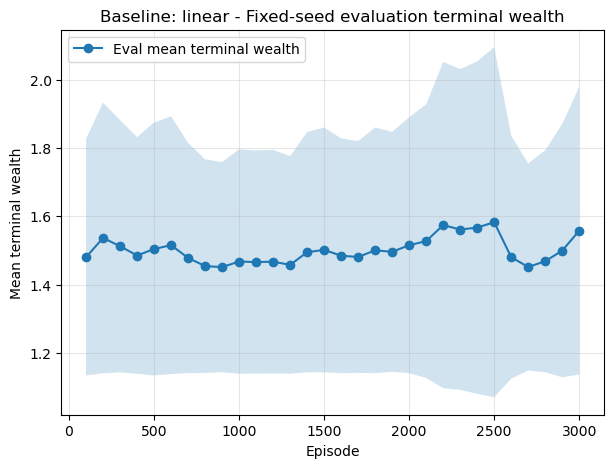



[neural] Episode  100 | Train utility (last100 mean) = -0.121712 | Critic loss = 0.000866 | Eval mean utility = -0.125329 | Eval mean wealth = 1.4483
[neural] Episode  200 | Train utility (last100 mean) = -0.127282 | Critic loss = 0.000663 | Eval mean utility = -0.123603 | Eval mean wealth = 1.4679
[neural] Episode  300 | Train utility (last100 mean) = -0.124918 | Critic loss = 0.000595 | Eval mean utility = -0.124168 | Eval mean wealth = 1.4626
[neural] Episode  400 | Train utility (last100 mean) = -0.118508 | Critic loss = 0.000514 | Eval mean utility = -0.122510 | Eval mean wealth = 1.4788
[neural] Episode  500 | Train utility (last100 mean) = -0.126361 | Critic loss = 0.000557 | Eval mean utility = -0.123037 | Eval mean wealth = 1.4747
[neural] Episode  600 | Train utility (last100 mean) = -0.115702 | Critic loss = 0.000472 | Eval mean utility = -0.119647 | Eval mean wealth = 1.5074
[neural] Episode  700 | Train utility (last100 mean) = -0.123067 | Critic loss = 0.000622 | Eval m

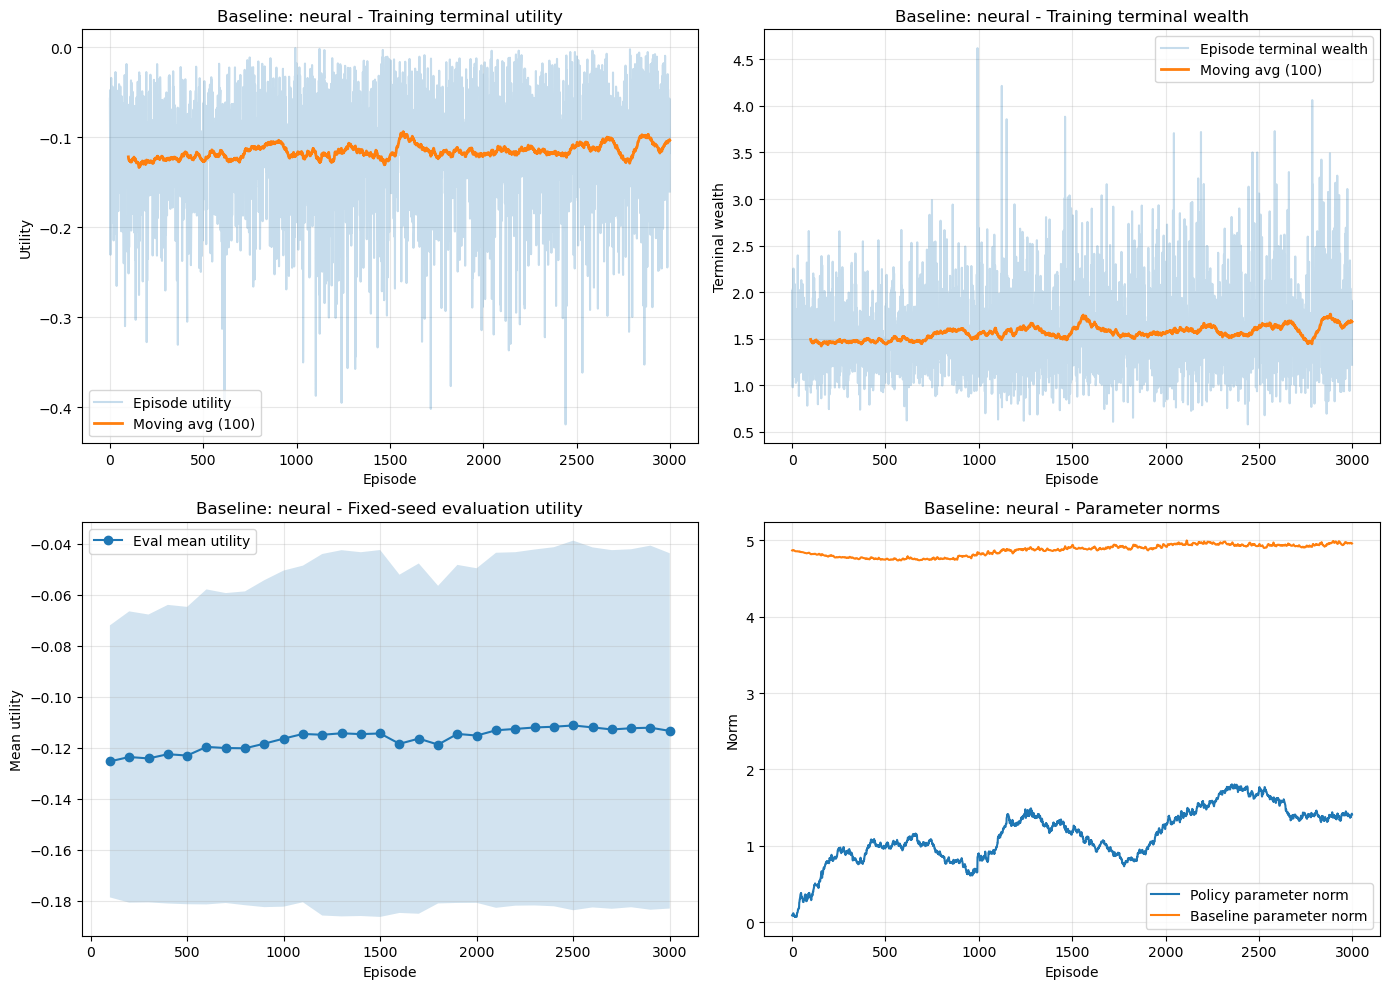

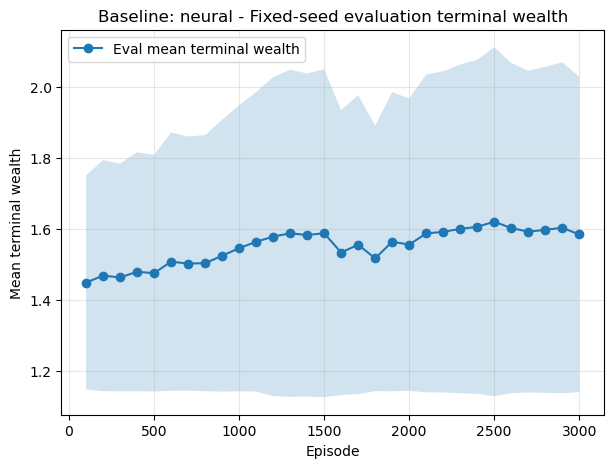

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


def cara_utility(w, risk_aversion):
    return -np.exp(-risk_aversion * w)


def project_to_simplex(v):
    v = np.asarray(v, dtype=float)
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    w = np.maximum(v - theta, 0.0)
    return w


def enforce_turnover_constraint(old_w, new_w, max_turnover=0.10):
    d = new_w - old_w
    l1 = np.sum(np.abs(d))
    if l1 <= max_turnover:
        return new_w
    alpha = max_turnover / (l1 + 1e-12)
    return old_w + alpha * d


def valid_portfolio_update(old_w, raw_delta, max_turnover=0.10):
    d = raw_delta - np.mean(raw_delta)

    l1 = np.sum(np.abs(d))
    if l1 > max_turnover:
        d = d * (max_turnover / (l1 + 1e-12))

    candidate = old_w + d
    candidate = project_to_simplex(candidate)
    candidate = enforce_turnover_constraint(old_w, candidate, max_turnover=max_turnover)
    candidate = project_to_simplex(candidate)

    return candidate


class AssetAllocationEnv:
    def __init__(self, means, variances, cash_rate, horizon, init_weights, init_wealth=1.0,
                 risk_aversion=1.0, seed=None):
        self.means = np.array(means, dtype=float)
        self.variances = np.array(variances, dtype=float)
        self.stds = np.sqrt(self.variances)
        self.n_risky = len(means)
        self.n_assets_total = self.n_risky + 1
        self.r = cash_rate
        self.T = horizon
        self.init_weights = np.array(init_weights, dtype=float)
        self.init_wealth = init_wealth
        self.risk_aversion = risk_aversion
        self.rng = np.random.default_rng(seed)

        assert len(self.init_weights) == self.n_assets_total
        assert np.isclose(np.sum(self.init_weights), 1.0)
        assert np.all(self.init_weights >= 0)
        assert self.T < 10
        assert self.n_risky < 5

        self.reset()

    def reset(self):
        self.t = 0
        self.wealth = self.init_wealth
        self.weights = self.init_weights.copy()
        return self._state()

    def _state(self):
        return np.concatenate(([self.t / self.T, np.log(max(self.wealth, 1e-8))], self.weights))

    def step(self, new_weights):
        new_weights = np.asarray(new_weights, dtype=float)

        risky_returns = self.rng.normal(self.means, self.stds)
        gross_returns = np.concatenate(([1.0 + self.r], 1.0 + risky_returns))

        portfolio_gross = np.dot(new_weights, gross_returns)
        next_wealth = self.wealth * portfolio_gross

        next_values = self.wealth * new_weights * gross_returns
        next_weights = next_values / np.sum(next_values)

        self.wealth = next_wealth
        self.weights = next_weights
        self.t += 1

        done = (self.t == self.T)
        reward = 0.0
        if done:
            reward = cara_utility(self.wealth, self.risk_aversion)

        return self._state(), reward, done, {
            "wealth": self.wealth,
            "weights": self.weights.copy(),
            "risky_returns": risky_returns,
            "gross_returns": gross_returns
        }


class LinearGaussianPolicy:
    def __init__(self, state_dim, action_dim, init_std=0.05, seed=None):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.rng = np.random.default_rng(seed)

        self.W = 0.01 * self.rng.normal(size=(action_dim, state_dim))
        self.b = np.zeros(action_dim)
        self.log_std = np.log(init_std) * np.ones(action_dim)

    def forward(self, state):
        mu = self.W @ state + self.b
        std = np.exp(self.log_std)
        return mu, std

    def sample_action(self, state):
        mu, std = self.forward(state)
        raw_action = mu + std * self.rng.normal(size=self.action_dim)
        z = (raw_action - mu) / std
        log_prob = -0.5 * np.sum(z**2 + 2*np.log(std) + np.log(2*np.pi))
        return raw_action, log_prob, mu, std

    def grad_log_prob(self, state, raw_action):
        mu, std = self.forward(state)
        diff = (raw_action - mu) / (std**2)
        grad_W = np.outer(diff, state)
        grad_b = diff
        return grad_W, grad_b

    def param_norm(self):
        return np.sqrt(np.sum(self.W**2) + np.sum(self.b**2))


# =========================
# Critic classes
# =========================

class NoCritic:
    def predict(self, state):
        return 0.0

    def update(self, state, target, lr=1e-2):
        td_error = target - self.predict(state)
        loss = td_error ** 2
        return float(loss), float(td_error)

    def param_norm(self):
        return 0.0

    @property
    def name(self):
        return "none"


class LinearValueCritic:
    def __init__(self, state_dim, seed=None):
        self.rng = np.random.default_rng(seed)
        self.w = np.zeros(state_dim)

    def predict(self, state):
        return float(np.dot(self.w, state))

    def update(self, state, target, lr=1e-2):
        state = np.asarray(state)
        pred = self.predict(state)
        td_error = target - pred
        self.w += lr * td_error * state
        loss = td_error ** 2
        return float(loss), float(td_error)

    def param_norm(self):
        return float(np.linalg.norm(self.w))

    @property
    def name(self):
        return "linear"


class NeuralValueCritic(nn.Module):
    def __init__(self, state_dim, hidden_dim=32, lr=1e-3, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, states):
        return self.net(states).squeeze(-1)

    def predict(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            value = self.forward(state_t).item()
        return float(value)

    def update(self, state, target, lr=None):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        target_t = torch.tensor([target], dtype=torch.float32)

        pred = self.forward(state_t)
        loss = self.loss_fn(pred, target_t)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        td_error = target - pred.item()
        return float(loss.item()), float(td_error)

    def param_norm(self):
        total = 0.0
        with torch.no_grad():
            for p in self.parameters():
                total += torch.sum(p ** 2).item()
        return float(np.sqrt(total))

    @property
    def name(self):
        return "neural"


def make_critic(critic_type, state_dim, critic_lr=1e-2, hidden_dim=32, seed=None):
    critic_type = critic_type.lower()

    if critic_type == "none":
        return NoCritic()
    elif critic_type == "linear":
        return LinearValueCritic(state_dim=state_dim, seed=seed)
    elif critic_type in ["neural", "nn", "mlp"]:
        return NeuralValueCritic(
            state_dim=state_dim,
            hidden_dim=hidden_dim,
            lr=critic_lr,
            seed=seed
        )
    else:
        raise ValueError(f"Unknown critic_type: {critic_type}")


def evaluate_policy(env_config, policy, n_eval=200, max_turnover=0.10, seed=999):
    utilities = []
    wealths = []

    for i in range(n_eval):
        env = AssetAllocationEnv(
            means=env_config["means"],
            variances=env_config["variances"],
            cash_rate=env_config["cash_rate"],
            horizon=env_config["horizon"],
            init_weights=env_config["init_weights"],
            init_wealth=env_config["init_wealth"],
            risk_aversion=env_config["risk_aversion"],
            seed=seed + i
        )

        state = env.reset()
        done = False

        while not done:
            mu, std = policy.forward(state)
            action_w = valid_portfolio_update(env.weights.copy(), mu, max_turnover=max_turnover)
            state, reward, done, info = env.step(action_w)

        utilities.append(reward)
        wealths.append(info["wealth"])

    return np.mean(utilities), np.std(utilities), np.mean(wealths), np.std(wealths)


def moving_average(x, window=100):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode='valid')


def train_actor_critic(env,
                       episodes=5000,
                       policy_lr=5e-3,
                       critic_type="linear",
                       critic_lr=1e-2,
                       critic_hidden_dim=32,
                       gamma=1.0,
                       max_turnover=0.10,
                       eval_every=100,
                       eval_paths=200,
                       seed=None):
    state_dim = 2 + env.n_assets_total
    action_dim = env.n_assets_total

    policy = LinearGaussianPolicy(state_dim, action_dim, init_std=0.05, seed=seed)
    critic = make_critic(
        critic_type=critic_type,
        state_dim=state_dim,
        critic_lr=critic_lr,
        hidden_dim=critic_hidden_dim,
        seed=seed
    )

    env_config = {
        "means": env.means.copy(),
        "variances": env.variances.copy(),
        "cash_rate": env.r,
        "horizon": env.T,
        "init_weights": env.init_weights.copy(),
        "init_wealth": env.init_wealth,
        "risk_aversion": env.risk_aversion
    }

    history = {
        "baseline_type": critic_type,   # 保持画图函数兼容
        "train_utility": [],
        "train_terminal_wealth": [],
        "policy_norm": [],
        "baseline_norm": [],
        "baseline_loss": [],
        "eval_episode": [],
        "eval_mean_utility": [],
        "eval_std_utility": [],
        "eval_mean_wealth": [],
        "eval_std_wealth": []
    }

    for ep in range(episodes):
        state = env.reset()
        done = False

        episode_reward = 0.0
        terminal_wealth = np.nan
        step_critic_losses = []

        while not done:
            raw_action, log_prob, mu, std = policy.sample_action(state)

            old_w = env.weights.copy()
            new_w = valid_portfolio_update(old_w, raw_action, max_turnover=max_turnover)

            next_state, reward, done, info = env.step(new_w)

            v_s = critic.predict(state)
            if done:
                td_target = reward
            else:
                v_next = critic.predict(next_state)
                td_target = reward + gamma * v_next

            critic_loss, td_error = critic.update(state, td_target, lr=critic_lr)

            grad_W, grad_b = policy.grad_log_prob(state, raw_action)
            policy.W += policy_lr * td_error * grad_W
            policy.b += policy_lr * td_error * grad_b

            step_critic_losses.append(critic_loss)
            episode_reward += reward
            terminal_wealth = info["wealth"]

            state = next_state

        history["train_utility"].append(episode_reward)
        history["train_terminal_wealth"].append(terminal_wealth)
        history["policy_norm"].append(policy.param_norm())
        history["baseline_norm"].append(critic.param_norm())
        history["baseline_loss"].append(np.mean(step_critic_losses) if len(step_critic_losses) > 0 else 0.0)

        if (ep + 1) % eval_every == 0:
            mean_u, std_u, mean_w, std_w = evaluate_policy(
                env_config,
                policy,
                n_eval=eval_paths,
                max_turnover=max_turnover,
                seed=999
            )
            history["eval_episode"].append(ep + 1)
            history["eval_mean_utility"].append(mean_u)
            history["eval_std_utility"].append(std_u)
            history["eval_mean_wealth"].append(mean_w)
            history["eval_std_wealth"].append(std_w)

            print(
                f"[{critic_type}] Episode {ep+1:4d} | "
                f"Train utility (last100 mean) = {np.mean(history['train_utility'][-100:]):.6f} | "
                f"Critic loss = {np.mean(history['baseline_loss'][-100:]):.6f} | "
                f"Eval mean utility = {mean_u:.6f} | "
                f"Eval mean wealth = {mean_w:.4f}"
            )

    return policy, critic, history


def plot_training_history(history, ma_window=100):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    title_prefix = f"Critic: {history.get('baseline_type', 'unknown')}"

    axes[0, 0].plot(history["train_utility"], alpha=0.25, label="Episode utility")
    ma_u = moving_average(history["train_utility"], ma_window)
    if len(ma_u) > 0:
        x_ma = np.arange(len(ma_u)) + (ma_window - 1 if len(history["train_utility"]) >= ma_window else 0)
        axes[0, 0].plot(x_ma, ma_u, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 0].set_title(f"{title_prefix} - Training terminal utility")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Utility")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history["train_terminal_wealth"], alpha=0.25, label="Episode terminal wealth")
    ma_w = moving_average(history["train_terminal_wealth"], ma_window)
    if len(ma_w) > 0:
        x_ma = np.arange(len(ma_w)) + (ma_window - 1 if len(history["train_terminal_wealth"]) >= ma_window else 0)
        axes[0, 1].plot(x_ma, ma_w, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 1].set_title(f"{title_prefix} - Training terminal wealth")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Terminal wealth")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    eval_ep = np.array(history["eval_episode"])
    eval_u = np.array(history["eval_mean_utility"])
    eval_u_std = np.array(history["eval_std_utility"])
    if len(eval_ep) > 0:
        axes[1, 0].plot(eval_ep, eval_u, marker='o', label="Eval mean utility")
        axes[1, 0].fill_between(eval_ep, eval_u - eval_u_std, eval_u + eval_u_std, alpha=0.2)
    axes[1, 0].set_title(f"{title_prefix} - Fixed-seed evaluation utility")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Mean utility")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(history["policy_norm"], label="Policy parameter norm")
    axes[1, 1].plot(history["baseline_norm"], label="Critic parameter norm")
    axes[1, 1].set_title(f"{title_prefix} - Parameter norms")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Norm")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_eval_wealth(history):
    plt.figure(figsize=(7, 5))
    eval_ep = np.array(history["eval_episode"])
    eval_w = np.array(history["eval_mean_wealth"])
    eval_w_std = np.array(history["eval_std_wealth"])
    if len(eval_ep) > 0:
        plt.plot(eval_ep, eval_w, marker='o', label="Eval mean terminal wealth")
        plt.fill_between(eval_ep, eval_w - eval_w_std, eval_w + eval_w_std, alpha=0.2)
    plt.title(f"Critic: {history.get('baseline_type', 'unknown')} - Fixed-seed evaluation terminal wealth")
    plt.xlabel("Episode")
    plt.ylabel("Mean terminal wealth")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    means = [0.08, 0.12, 0.05]
    variances = [0.04, 0.09, 0.02]
    cash_rate = 0.03
    horizon = 6
    init_weights = [0.25, 0.25, 0.30, 0.20]   # cash + 3 risky assets
    risk_aversion = 1.5

    for critic_type in ["none", "linear", "neural"]:
        env = AssetAllocationEnv(
            means=means,
            variances=variances,
            cash_rate=cash_rate,
            horizon=horizon,
            init_weights=init_weights,
            init_wealth=1.0,
            risk_aversion=risk_aversion,
            seed=123
        )

        policy, critic, history = train_actor_critic(
            env,
            episodes=3000,
            policy_lr=0.01,
            critic_type=critic_type,
            critic_lr=1e-3,
            critic_hidden_dim=32,
            gamma=1.0,
            max_turnover=0.10,
            eval_every=100,
            eval_paths=200,
            seed=123
        )

        print("=" * 80)
        print("\n")
        print(f"Finished training with critic: {critic_type}")
        plot_training_history(history, ma_window=100)
        plot_eval_wealth(history)
        print("\n")

# Neural Gaussian Policy + Neural Critic

[scheme B] Episode  100 | Train utility (last100 mean) = -0.112009 | Critic loss = 0.000682 | Eval mean utility = -0.115591 | Eval mean wealth = 1.5223
[scheme B] Episode  200 | Train utility (last100 mean) = -0.119861 | Critic loss = 0.000481 | Eval mean utility = -0.116333 | Eval mean wealth = 1.5063
[scheme B] Episode  300 | Train utility (last100 mean) = -0.117820 | Critic loss = 0.000463 | Eval mean utility = -0.114314 | Eval mean wealth = 1.5281
[scheme B] Episode  400 | Train utility (last100 mean) = -0.111643 | Critic loss = 0.000558 | Eval mean utility = -0.113822 | Eval mean wealth = 1.5333
[scheme B] Episode  500 | Train utility (last100 mean) = -0.118087 | Critic loss = 0.000499 | Eval mean utility = -0.113497 | Eval mean wealth = 1.5384
[scheme B] Episode  600 | Train utility (last100 mean) = -0.104475 | Critic loss = 0.000497 | Eval mean utility = -0.113488 | Eval mean wealth = 1.5382
[scheme B] Episode  700 | Train utility (last100 mean) = -0.119655 | Critic loss = 0.000

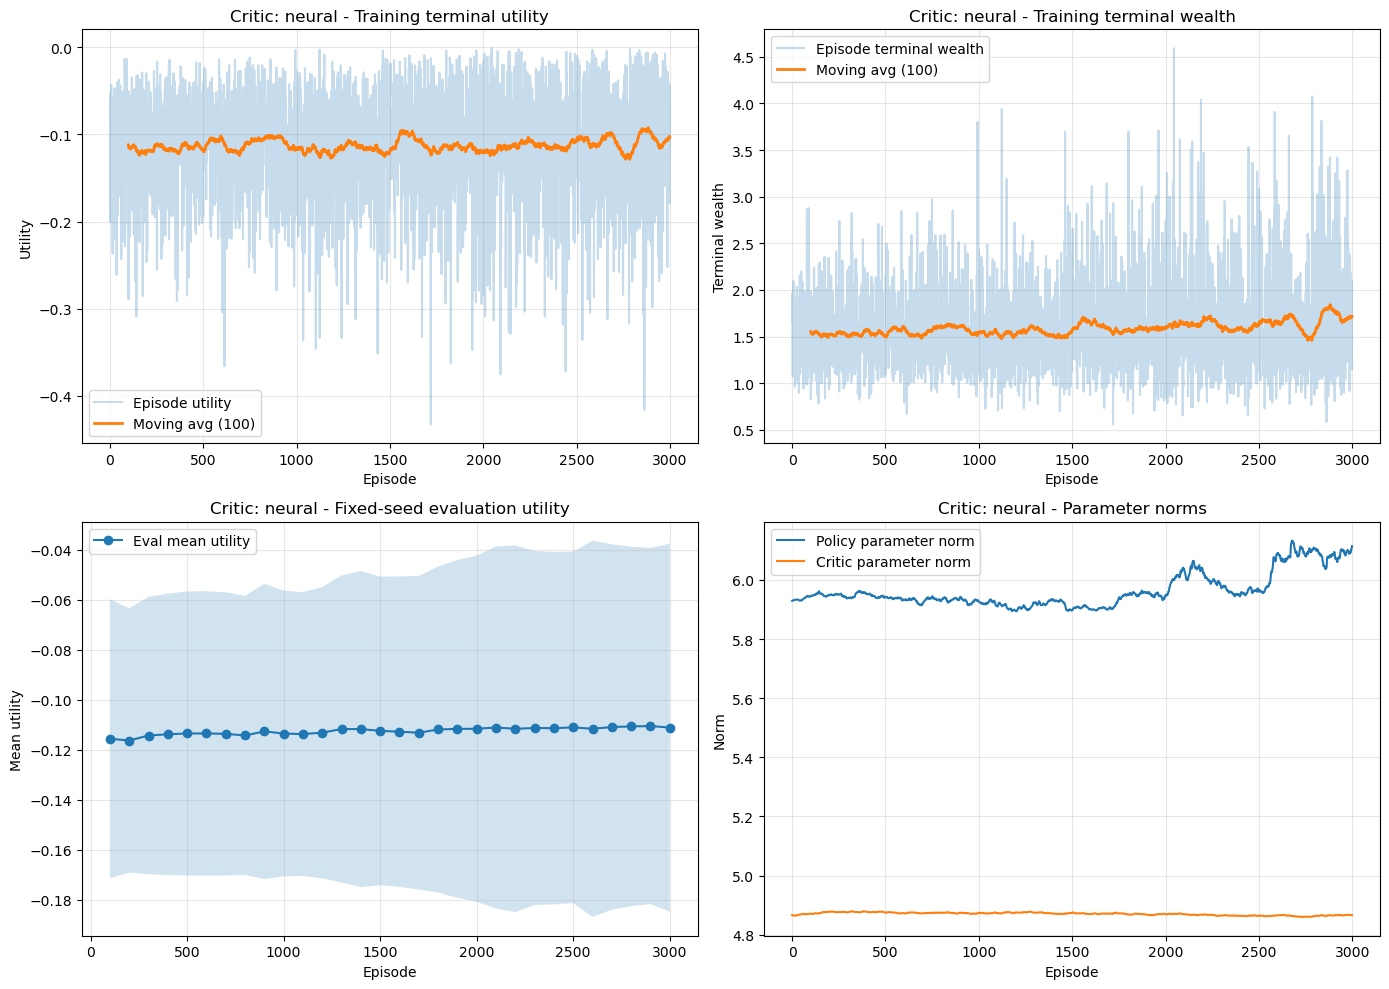

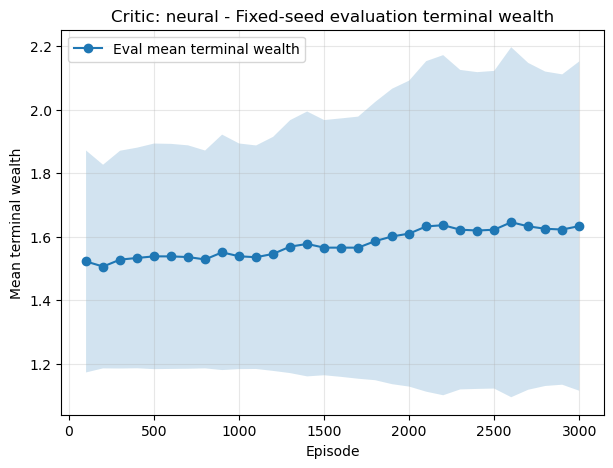

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


def cara_utility(w, risk_aversion):
    return -np.exp(-risk_aversion * w)


def project_to_simplex(v):
    v = np.asarray(v, dtype=float)
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    w = np.maximum(v - theta, 0.0)
    return w


def apply_turnover_toward_target(old_w, target_w, max_turnover=0.10):
    old_w = np.asarray(old_w, dtype=float)
    target_w = np.asarray(target_w, dtype=float)

    # 数值安全：保证 target_w 合法
    target_w = np.clip(target_w, 0.0, 1.0)
    target_w = target_w / (np.sum(target_w) + 1e-12)

    diff = target_w - old_w
    l1 = np.sum(np.abs(diff))

    if l1 <= max_turnover + 1e-12:
        new_w = target_w.copy()
    else:
        alpha = max_turnover / (l1 + 1e-12)
        new_w = old_w + alpha * diff

    # 数值安全
    new_w = np.clip(new_w, 0.0, 1.0)
    new_w = new_w / (np.sum(new_w) + 1e-12)
    return new_w


class AssetAllocationEnv:
    def __init__(self, means, variances, cash_rate, horizon, init_weights, init_wealth=1.0,
                 risk_aversion=1.0, seed=None):
        self.means = np.array(means, dtype=float)
        self.variances = np.array(variances, dtype=float)
        self.stds = np.sqrt(self.variances)
        self.n_risky = len(means)
        self.n_assets_total = self.n_risky + 1
        self.r = cash_rate
        self.T = horizon
        self.init_weights = np.array(init_weights, dtype=float)
        self.init_wealth = init_wealth
        self.risk_aversion = risk_aversion
        self.rng = np.random.default_rng(seed)

        assert len(self.init_weights) == self.n_assets_total
        assert np.isclose(np.sum(self.init_weights), 1.0)
        assert np.all(self.init_weights >= 0)
        assert self.T < 10
        assert self.n_risky < 5

        self.reset()

    def reset(self):
        self.t = 0
        self.wealth = self.init_wealth
        self.weights = self.init_weights.copy()
        return self._state()

    def _state(self):
        return np.concatenate(([self.t / self.T, np.log(max(self.wealth, 1e-8))], self.weights))

    def step(self, new_weights):
        new_weights = np.asarray(new_weights, dtype=float)

        risky_returns = self.rng.normal(self.means, self.stds)
        gross_returns = np.concatenate(([1.0 + self.r], 1.0 + risky_returns))

        portfolio_gross = np.dot(new_weights, gross_returns)
        next_wealth = self.wealth * portfolio_gross

        next_values = self.wealth * new_weights * gross_returns
        next_weights = next_values / np.sum(next_values)

        self.wealth = next_wealth
        self.weights = next_weights
        self.t += 1

        done = (self.t == self.T)
        reward = 0.0
        if done:
            reward = cara_utility(self.wealth, self.risk_aversion)

        return self._state(), reward, done, {
            "wealth": self.wealth,
            "weights": self.weights.copy(),
            "risky_returns": risky_returns,
            "gross_returns": gross_returns
        }


class NeuralGaussianPolicyB(nn.Module):
    """
    方案 B:
    网络输出 Gaussian logits
    sampled logits --softmax--> target weights
    deterministic 时使用 mu --softmax--> target weights
    """
    def __init__(self, state_dim, action_dim, hidden_dim=32, init_std=0.20, lr=1e-3, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, action_dim)
        )

        # 用更直接稳定的参数化
        init_log_std = np.log(init_std)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_log_std)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if isinstance(state, np.ndarray):
            state = torch.tensor(state, dtype=torch.float32)
        if state.dim() == 1:
            state = state.unsqueeze(0)

        mu = self.net(state)
        log_std = torch.clamp(self.log_std, min=-4.0, max=1.0)
        std = torch.exp(log_std).unsqueeze(0).expand_as(mu)
        return mu, std

    def sample_action(self, state):
        if isinstance(state, np.ndarray):
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        else:
            state_t = state
            if state_t.dim() == 1:
                state_t = state_t.unsqueeze(0)

        mu, std = self.forward(state_t)
        dist = torch.distributions.Normal(mu, std)

        logits_t = dist.rsample()
        
        # ✅ 关键修复：detach 采样值，使 log_prob 对 mu 的梯度不再抵消
        log_prob_t = dist.log_prob(logits_t.detach()).sum(dim=-1)
        entropy_t = dist.entropy().sum(dim=-1)

        target_w_t = F.softmax(logits_t, dim=-1)

        return {
            "logits": logits_t.squeeze(0),
            "log_prob": log_prob_t.squeeze(0),
            "entropy": entropy_t.squeeze(0),
            "mu": mu.squeeze(0),
            "std": std.squeeze(0),
            "target_w": target_w_t.squeeze(0)
        }

    def deterministic_action(self, state):
        with torch.no_grad():
            mu, _ = self.forward(state)
            target_w = F.softmax(mu, dim=-1)
        return {
            "mu": mu.squeeze(0).cpu().numpy(),
            "target_w": target_w.squeeze(0).cpu().numpy()
        }

    def param_norm(self):
        total = 0.0
        with torch.no_grad():
            for p in self.parameters():
                total += torch.sum(p ** 2).item()
        return float(np.sqrt(total))


class NeuralValueCritic(nn.Module):
    def __init__(self, state_dim, hidden_dim=32, lr=1e-3, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, states):
        return self.net(states).squeeze(-1)

    def predict(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            value = self.forward(state_t).item()
        return float(value)

    def update(self, state, target):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        target_t = torch.tensor([target], dtype=torch.float32)

        pred = self.forward(state_t)
        loss = self.loss_fn(pred, target_t)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        td_error = target - pred.item()
        return float(loss.item()), float(td_error)

    def param_norm(self):
        total = 0.0
        with torch.no_grad():
            for p in self.parameters():
                total += torch.sum(p ** 2).item()
        return float(np.sqrt(total))


def evaluate_policy(env_config, policy, n_eval=200, max_turnover=0.10, seed=999, stochastic=False):
    utilities = []
    wealths = []

    for i in range(n_eval):
        env = AssetAllocationEnv(
            means=env_config["means"],
            variances=env_config["variances"],
            cash_rate=env_config["cash_rate"],
            horizon=env_config["horizon"],
            init_weights=env_config["init_weights"],
            init_wealth=env_config["init_wealth"],
            risk_aversion=env_config["risk_aversion"],
            seed=seed + i
        )

        state = env.reset()
        done = False

        while not done:
            if stochastic:
                out = policy.sample_action(state)
                target_w = out["target_w"].detach().cpu().numpy()
            else:
                out = policy.deterministic_action(state)
                target_w = out["target_w"]

            action_w = apply_turnover_toward_target(
                env.weights.copy(),
                target_w,
                max_turnover=max_turnover
            )

            state, reward, done, info = env.step(action_w)

        utilities.append(reward)
        wealths.append(info["wealth"])

    return np.mean(utilities), np.std(utilities), np.mean(wealths), np.std(wealths)


def moving_average(x, window=100):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode='valid')


def train_actor_critic(env,
                       episodes=5000,
                       policy_lr=1e-3,
                       critic_lr=1e-3,
                       policy_hidden_dim=32,
                       critic_hidden_dim=32,
                       gamma=1.0,
                       max_turnover=0.10,
                       eval_every=100,
                       eval_paths=200,
                       seed=None,
                       entropy_coef=1e-3,
                       advantage_clip=5.0):
    state_dim = 2 + env.n_assets_total
    action_dim = env.n_assets_total

    policy = NeuralGaussianPolicyB(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=policy_hidden_dim,
        init_std=0.20,
        lr=policy_lr,
        seed=seed
    )

    critic = NeuralValueCritic(
        state_dim=state_dim,
        hidden_dim=critic_hidden_dim,
        lr=critic_lr,
        seed=seed
    )

    env_config = {
        "means": env.means.copy(),
        "variances": env.variances.copy(),
        "cash_rate": env.r,
        "horizon": env.T,
        "init_weights": env.init_weights.copy(),
        "init_wealth": env.init_wealth,
        "risk_aversion": env.risk_aversion
    }

    history = {
        "baseline_type": "neural",
        "train_utility": [],
        "train_terminal_wealth": [],
        "policy_norm": [],
        "baseline_norm": [],
        "baseline_loss": [],
        "eval_episode": [],
        "eval_mean_utility": [],
        "eval_std_utility": [],
        "eval_mean_wealth": [],
        "eval_std_wealth": []
    }

    for ep in range(episodes):
        state = env.reset()
        done = False

        episode_reward = 0.0
        terminal_wealth = np.nan
        step_critic_losses = []

        while not done:
            out = policy.sample_action(state)

            log_prob = out["log_prob"]
            entropy = out["entropy"]
            target_w = out["target_w"].detach().cpu().numpy()

            old_w = env.weights.copy()
            new_w = apply_turnover_toward_target(
                old_w,
                target_w,
                max_turnover=max_turnover
            )

            next_state, reward, done, info = env.step(new_w)

            v_s = critic.predict(state)
            if done:
                td_target = reward
            else:
                v_next = critic.predict(next_state)
                td_target = reward + gamma * v_next

            critic_loss, td_error = critic.update(state, td_target)

            adv = np.clip(td_error, -advantage_clip, advantage_clip)
            adv_t = torch.tensor(adv, dtype=torch.float32)

            actor_loss = -(log_prob * adv_t) - entropy_coef * entropy

            policy.optimizer.zero_grad()
            actor_loss.backward()
            policy.optimizer.step()

            step_critic_losses.append(critic_loss)
            episode_reward += reward
            terminal_wealth = info["wealth"]

            state = next_state

        history["train_utility"].append(episode_reward)
        history["train_terminal_wealth"].append(terminal_wealth)
        history["policy_norm"].append(policy.param_norm())
        history["baseline_norm"].append(critic.param_norm())
        history["baseline_loss"].append(np.mean(step_critic_losses) if len(step_critic_losses) > 0 else 0.0)

        if (ep + 1) % eval_every == 0:
            mean_u, std_u, mean_w, std_w = evaluate_policy(
                env_config,
                policy,
                n_eval=eval_paths,
                max_turnover=max_turnover,
                seed=999,
                stochastic=False
            )
            history["eval_episode"].append(ep + 1)
            history["eval_mean_utility"].append(mean_u)
            history["eval_std_utility"].append(std_u)
            history["eval_mean_wealth"].append(mean_w)
            history["eval_std_wealth"].append(std_w)

            print(
                f"[scheme B] Episode {ep+1:4d} | "
                f"Train utility (last100 mean) = {np.mean(history['train_utility'][-100:]):.6f} | "
                f"Critic loss = {np.mean(history['baseline_loss'][-100:]):.6f} | "
                f"Eval mean utility = {mean_u:.6f} | "
                f"Eval mean wealth = {mean_w:.4f}"
            )

    return policy, critic, history


def plot_training_history(history, ma_window=100):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    title_prefix = f"Critic: {history.get('baseline_type', 'unknown')}"

    axes[0, 0].plot(history["train_utility"], alpha=0.25, label="Episode utility")
    ma_u = moving_average(history["train_utility"], ma_window)
    if len(ma_u) > 0:
        x_ma = np.arange(len(ma_u)) + (ma_window - 1 if len(history["train_utility"]) >= ma_window else 0)
        axes[0, 0].plot(x_ma, ma_u, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 0].set_title(f"{title_prefix} - Training terminal utility")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Utility")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history["train_terminal_wealth"], alpha=0.25, label="Episode terminal wealth")
    ma_w = moving_average(history["train_terminal_wealth"], ma_window)
    if len(ma_w) > 0:
        x_ma = np.arange(len(ma_w)) + (ma_window - 1 if len(history["train_terminal_wealth"]) >= ma_window else 0)
        axes[0, 1].plot(x_ma, ma_w, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 1].set_title(f"{title_prefix} - Training terminal wealth")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Terminal wealth")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    eval_ep = np.array(history["eval_episode"])
    eval_u = np.array(history["eval_mean_utility"])
    eval_u_std = np.array(history["eval_std_utility"])
    if len(eval_ep) > 0:
        axes[1, 0].plot(eval_ep, eval_u, marker='o', label="Eval mean utility")
        axes[1, 0].fill_between(eval_ep, eval_u - eval_u_std, eval_u + eval_u_std, alpha=0.2)
    axes[1, 0].set_title(f"{title_prefix} - Fixed-seed evaluation utility")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Mean utility")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(history["policy_norm"], label="Policy parameter norm")
    axes[1, 1].plot(history["baseline_norm"], label="Critic parameter norm")
    axes[1, 1].set_title(f"{title_prefix} - Parameter norms")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Norm")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_eval_wealth(history):
    plt.figure(figsize=(7, 5))
    eval_ep = np.array(history["eval_episode"])
    eval_w = np.array(history["eval_mean_wealth"])
    eval_w_std = np.array(history["eval_std_wealth"])
    if len(eval_ep) > 0:
        plt.plot(eval_ep, eval_w, marker='o', label="Eval mean terminal wealth")
        plt.fill_between(eval_ep, eval_w - eval_w_std, eval_w + eval_w_std, alpha=0.2)
    plt.title(f"Critic: {history.get('baseline_type', 'unknown')} - Fixed-seed evaluation terminal wealth")
    plt.xlabel("Episode")
    plt.ylabel("Mean terminal wealth")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    means = [0.08, 0.12, 0.05]
    variances = [0.04, 0.09, 0.02]
    cash_rate = 0.03
    horizon = 6
    init_weights = [0.25, 0.25, 0.30, 0.20]   # cash + 3 risky assets
    risk_aversion = 1.5

    env = AssetAllocationEnv(
        means=means,
        variances=variances,
        cash_rate=cash_rate,
        horizon=horizon,
        init_weights=init_weights,
        init_wealth=1.0,
        risk_aversion=risk_aversion,
        seed=123
    )

    policy, critic, history = train_actor_critic(
        env,
        episodes=3000,
        policy_lr=3e-4,
        critic_lr=1e-4,
        policy_hidden_dim=32,
        critic_hidden_dim=32,
        gamma=1.0,
        max_turnover=0.10,
        eval_every=100,
        eval_paths=200,
        seed=123,
        entropy_coef=5e-4,
        advantage_clip=5.0
    )

    print("=" * 80)
    print("\nFinished training with scheme B: target-weights Gaussian policy + neural critic")
    plot_training_history(history, ma_window=100)
    plot_eval_wealth(history)

## StepLR adaptive LR

[scheme B] Episode  100 | Train utility (last100 mean) = -0.112009 | Critic loss = 0.000682 | Policy LR = 3.000000e-04 | Critic LR = 1.000000e-04 | Eval mean utility = -0.115591 | Eval mean wealth = 1.5223
[scheme B] Episode  200 | Train utility (last100 mean) = -0.119861 | Critic loss = 0.000481 | Policy LR = 3.000000e-04 | Critic LR = 1.000000e-04 | Eval mean utility = -0.116333 | Eval mean wealth = 1.5063
[scheme B] Episode  300 | Train utility (last100 mean) = -0.117820 | Critic loss = 0.000463 | Policy LR = 3.000000e-04 | Critic LR = 1.000000e-04 | Eval mean utility = -0.114314 | Eval mean wealth = 1.5281
[scheme B] Episode  400 | Train utility (last100 mean) = -0.111643 | Critic loss = 0.000558 | Policy LR = 3.000000e-04 | Critic LR = 1.000000e-04 | Eval mean utility = -0.113822 | Eval mean wealth = 1.5333
[scheme B] Episode  500 | Train utility (last100 mean) = -0.118087 | Critic loss = 0.000499 | Policy LR = 3.000000e-04 | Critic LR = 1.000000e-04 | Eval mean utility = -0.11349

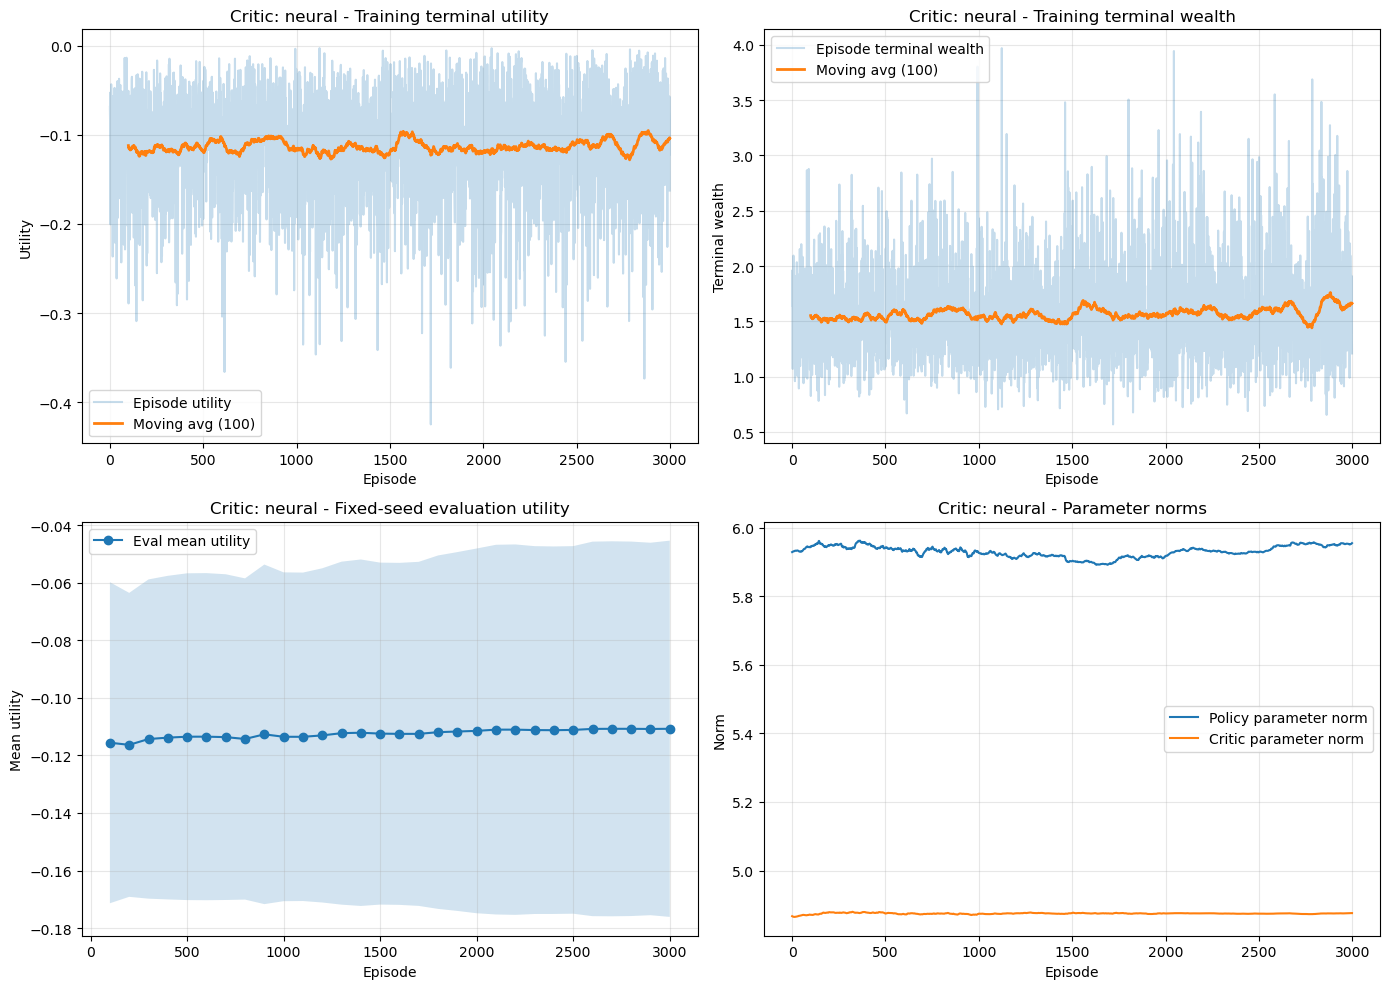

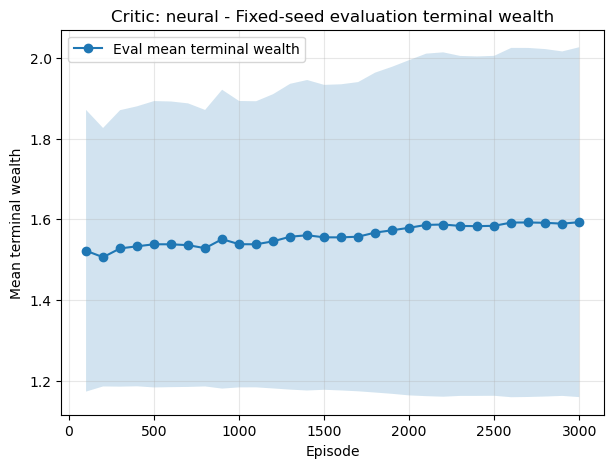

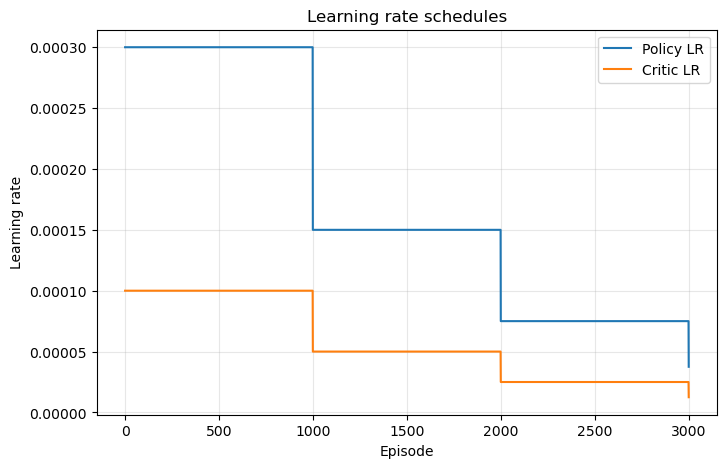

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


def cara_utility(w, risk_aversion):
    return -np.exp(-risk_aversion * w)


def project_to_simplex(v):
    v = np.asarray(v, dtype=float)
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    w = np.maximum(v - theta, 0.0)
    return w


def apply_turnover_toward_target(old_w, target_w, max_turnover=0.10):
    old_w = np.asarray(old_w, dtype=float)
    target_w = np.asarray(target_w, dtype=float)

    # 数值安全：保证 target_w 合法
    target_w = np.clip(target_w, 0.0, 1.0)
    target_w = target_w / (np.sum(target_w) + 1e-12)

    diff = target_w - old_w
    l1 = np.sum(np.abs(diff))

    if l1 <= max_turnover + 1e-12:
        new_w = target_w.copy()
    else:
        alpha = max_turnover / (l1 + 1e-12)
        new_w = old_w + alpha * diff

    # 数值安全
    new_w = np.clip(new_w, 0.0, 1.0)
    new_w = new_w / (np.sum(new_w) + 1e-12)
    return new_w


class AssetAllocationEnv:
    def __init__(self, means, variances, cash_rate, horizon, init_weights, init_wealth=1.0,
                 risk_aversion=1.0, seed=None):
        self.means = np.array(means, dtype=float)
        self.variances = np.array(variances, dtype=float)
        self.stds = np.sqrt(self.variances)
        self.n_risky = len(means)
        self.n_assets_total = self.n_risky + 1
        self.r = cash_rate
        self.T = horizon
        self.init_weights = np.array(init_weights, dtype=float)
        self.init_wealth = init_wealth
        self.risk_aversion = risk_aversion
        self.rng = np.random.default_rng(seed)

        assert len(self.init_weights) == self.n_assets_total
        assert np.isclose(np.sum(self.init_weights), 1.0)
        assert np.all(self.init_weights >= 0)
        assert self.T < 10
        assert self.n_risky < 5

        self.reset()

    def reset(self):
        self.t = 0
        self.wealth = self.init_wealth
        self.weights = self.init_weights.copy()
        return self._state()

    def _state(self):
        return np.concatenate(([self.t / self.T, np.log(max(self.wealth, 1e-8))], self.weights))

    def step(self, new_weights):
        new_weights = np.asarray(new_weights, dtype=float)

        risky_returns = self.rng.normal(self.means, self.stds)
        gross_returns = np.concatenate(([1.0 + self.r], 1.0 + risky_returns))

        portfolio_gross = np.dot(new_weights, gross_returns)
        next_wealth = self.wealth * portfolio_gross

        next_values = self.wealth * new_weights * gross_returns
        next_weights = next_values / np.sum(next_values)

        self.wealth = next_wealth
        self.weights = next_weights
        self.t += 1

        done = (self.t == self.T)
        reward = 0.0
        if done:
            reward = cara_utility(self.wealth, self.risk_aversion)

        return self._state(), reward, done, {
            "wealth": self.wealth,
            "weights": self.weights.copy(),
            "risky_returns": risky_returns,
            "gross_returns": gross_returns
        }


class NeuralGaussianPolicyB(nn.Module):
    """
    方案 B:
    网络输出 Gaussian logits
    sampled logits --softmax--> target weights
    deterministic 时使用 mu --softmax--> target weights
    """
    def __init__(self, state_dim, action_dim, hidden_dim=32, init_std=0.20, lr=1e-3, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, action_dim)
        )

        # 用更直接稳定的参数化
        init_log_std = np.log(init_std)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_log_std)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if isinstance(state, np.ndarray):
            state = torch.tensor(state, dtype=torch.float32)
        if state.dim() == 1:
            state = state.unsqueeze(0)

        mu = self.net(state)
        log_std = torch.clamp(self.log_std, min=-4.0, max=1.0)
        std = torch.exp(log_std).unsqueeze(0).expand_as(mu)
        return mu, std

    def sample_action(self, state):
        if isinstance(state, np.ndarray):
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        else:
            state_t = state
            if state_t.dim() == 1:
                state_t = state_t.unsqueeze(0)

        mu, std = self.forward(state_t)
        dist = torch.distributions.Normal(mu, std)

        logits_t = dist.rsample()

        # detach 采样值，使 log_prob 对 mu 的梯度不再抵消
        log_prob_t = dist.log_prob(logits_t.detach()).sum(dim=-1)
        entropy_t = dist.entropy().sum(dim=-1)

        target_w_t = F.softmax(logits_t, dim=-1)

        return {
            "logits": logits_t.squeeze(0),
            "log_prob": log_prob_t.squeeze(0),
            "entropy": entropy_t.squeeze(0),
            "mu": mu.squeeze(0),
            "std": std.squeeze(0),
            "target_w": target_w_t.squeeze(0)
        }

    def deterministic_action(self, state):
        with torch.no_grad():
            mu, _ = self.forward(state)
            target_w = F.softmax(mu, dim=-1)
        return {
            "mu": mu.squeeze(0).cpu().numpy(),
            "target_w": target_w.squeeze(0).cpu().numpy()
        }

    def param_norm(self):
        total = 0.0
        with torch.no_grad():
            for p in self.parameters():
                total += torch.sum(p ** 2).item()
        return float(np.sqrt(total))


class NeuralValueCritic(nn.Module):
    def __init__(self, state_dim, hidden_dim=32, lr=1e-3, seed=None):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, states):
        return self.net(states).squeeze(-1)

    def predict(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            value = self.forward(state_t).item()
        return float(value)

    def update(self, state, target):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        target_t = torch.tensor([target], dtype=torch.float32)

        pred = self.forward(state_t)
        loss = self.loss_fn(pred, target_t)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        td_error = target - pred.item()
        return float(loss.item()), float(td_error)

    def param_norm(self):
        total = 0.0
        with torch.no_grad():
            for p in self.parameters():
                total += torch.sum(p ** 2).item()
        return float(np.sqrt(total))


def evaluate_policy(env_config, policy, n_eval=200, max_turnover=0.10, seed=999, stochastic=False):
    utilities = []
    wealths = []

    for i in range(n_eval):
        env = AssetAllocationEnv(
            means=env_config["means"],
            variances=env_config["variances"],
            cash_rate=env_config["cash_rate"],
            horizon=env_config["horizon"],
            init_weights=env_config["init_weights"],
            init_wealth=env_config["init_wealth"],
            risk_aversion=env_config["risk_aversion"],
            seed=seed + i
        )

        state = env.reset()
        done = False

        while not done:
            if stochastic:
                out = policy.sample_action(state)
                target_w = out["target_w"].detach().cpu().numpy()
            else:
                out = policy.deterministic_action(state)
                target_w = out["target_w"]

            action_w = apply_turnover_toward_target(
                env.weights.copy(),
                target_w,
                max_turnover=max_turnover
            )

            state, reward, done, info = env.step(action_w)

        utilities.append(reward)
        wealths.append(info["wealth"])

    return np.mean(utilities), np.std(utilities), np.mean(wealths), np.std(wealths)


def moving_average(x, window=100):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode='valid')


def train_actor_critic(env,
                       episodes=5000,
                       policy_lr=1e-3,
                       critic_lr=1e-3,
                       policy_hidden_dim=32,
                       critic_hidden_dim=32,
                       gamma=1.0,
                       max_turnover=0.10,
                       eval_every=100,
                       eval_paths=200,
                       seed=None,
                       entropy_coef=1e-3,
                       advantage_clip=5.0,
                       use_lr_scheduler=True,
                       policy_step_size=1000,
                       critic_step_size=1000,
                       policy_lr_gamma=0.5,
                       critic_lr_gamma=0.5):
    state_dim = 2 + env.n_assets_total
    action_dim = env.n_assets_total

    policy = NeuralGaussianPolicyB(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=policy_hidden_dim,
        init_std=0.20,
        lr=policy_lr,
        seed=seed
    )

    critic = NeuralValueCritic(
        state_dim=state_dim,
        hidden_dim=critic_hidden_dim,
        lr=critic_lr,
        seed=seed
    )

    # 新增：StepLR 调度器（最小改动版）
    if use_lr_scheduler:
        policy_scheduler = optim.lr_scheduler.StepLR(
            policy.optimizer,
            step_size=policy_step_size,
            gamma=policy_lr_gamma
        )
        critic_scheduler = optim.lr_scheduler.StepLR(
            critic.optimizer,
            step_size=critic_step_size,
            gamma=critic_lr_gamma
        )
    else:
        policy_scheduler = None
        critic_scheduler = None

    env_config = {
        "means": env.means.copy(),
        "variances": env.variances.copy(),
        "cash_rate": env.r,
        "horizon": env.T,
        "init_weights": env.init_weights.copy(),
        "init_wealth": env.init_wealth,
        "risk_aversion": env.risk_aversion
    }

    history = {
        "baseline_type": "neural",
        "train_utility": [],
        "train_terminal_wealth": [],
        "policy_norm": [],
        "baseline_norm": [],
        "baseline_loss": [],
        "policy_lr": [],
        "critic_lr": [],
        "eval_episode": [],
        "eval_mean_utility": [],
        "eval_std_utility": [],
        "eval_mean_wealth": [],
        "eval_std_wealth": []
    }

    for ep in range(episodes):
        state = env.reset()
        done = False

        episode_reward = 0.0
        terminal_wealth = np.nan
        step_critic_losses = []

        while not done:
            out = policy.sample_action(state)

            log_prob = out["log_prob"]
            entropy = out["entropy"]
            target_w = out["target_w"].detach().cpu().numpy()

            old_w = env.weights.copy()
            new_w = apply_turnover_toward_target(
                old_w,
                target_w,
                max_turnover=max_turnover
            )

            next_state, reward, done, info = env.step(new_w)

            v_s = critic.predict(state)
            if done:
                td_target = reward
            else:
                v_next = critic.predict(next_state)
                td_target = reward + gamma * v_next

            critic_loss, td_error = critic.update(state, td_target)

            adv = np.clip(td_error, -advantage_clip, advantage_clip)
            adv_t = torch.tensor(adv, dtype=torch.float32)

            actor_loss = -(log_prob * adv_t) - entropy_coef * entropy

            policy.optimizer.zero_grad()
            actor_loss.backward()
            policy.optimizer.step()

            step_critic_losses.append(critic_loss)
            episode_reward += reward
            terminal_wealth = info["wealth"]

            state = next_state

        # 每个 episode 结束后更新 scheduler
        if policy_scheduler is not None:
            policy_scheduler.step()
        if critic_scheduler is not None:
            critic_scheduler.step()

        # 记录当前学习率
        current_policy_lr = policy.optimizer.param_groups[0]["lr"]
        current_critic_lr = critic.optimizer.param_groups[0]["lr"]

        history["train_utility"].append(episode_reward)
        history["train_terminal_wealth"].append(terminal_wealth)
        history["policy_norm"].append(policy.param_norm())
        history["baseline_norm"].append(critic.param_norm())
        history["baseline_loss"].append(np.mean(step_critic_losses) if len(step_critic_losses) > 0 else 0.0)
        history["policy_lr"].append(current_policy_lr)
        history["critic_lr"].append(current_critic_lr)

        if (ep + 1) % eval_every == 0:
            mean_u, std_u, mean_w, std_w = evaluate_policy(
                env_config,
                policy,
                n_eval=eval_paths,
                max_turnover=max_turnover,
                seed=999,
                stochastic=False
            )
            history["eval_episode"].append(ep + 1)
            history["eval_mean_utility"].append(mean_u)
            history["eval_std_utility"].append(std_u)
            history["eval_mean_wealth"].append(mean_w)
            history["eval_std_wealth"].append(std_w)

            print(
                f"[scheme B] Episode {ep+1:4d} | "
                f"Train utility (last100 mean) = {np.mean(history['train_utility'][-100:]):.6f} | "
                f"Critic loss = {np.mean(history['baseline_loss'][-100:]):.6f} | "
                f"Policy LR = {current_policy_lr:.6e} | "
                f"Critic LR = {current_critic_lr:.6e} | "
                f"Eval mean utility = {mean_u:.6f} | "
                f"Eval mean wealth = {mean_w:.4f}"
            )

    return policy, critic, history


def plot_training_history(history, ma_window=100):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    title_prefix = f"Critic: {history.get('baseline_type', 'unknown')}"

    axes[0, 0].plot(history["train_utility"], alpha=0.25, label="Episode utility")
    ma_u = moving_average(history["train_utility"], ma_window)
    if len(ma_u) > 0:
        x_ma = np.arange(len(ma_u)) + (ma_window - 1 if len(history["train_utility"]) >= ma_window else 0)
        axes[0, 0].plot(x_ma, ma_u, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 0].set_title(f"{title_prefix} - Training terminal utility")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Utility")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history["train_terminal_wealth"], alpha=0.25, label="Episode terminal wealth")
    ma_w = moving_average(history["train_terminal_wealth"], ma_window)
    if len(ma_w) > 0:
        x_ma = np.arange(len(ma_w)) + (ma_window - 1 if len(history["train_terminal_wealth"]) >= ma_window else 0)
        axes[0, 1].plot(x_ma, ma_w, linewidth=2, label=f"Moving avg ({ma_window})")
    axes[0, 1].set_title(f"{title_prefix} - Training terminal wealth")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Terminal wealth")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    eval_ep = np.array(history["eval_episode"])
    eval_u = np.array(history["eval_mean_utility"])
    eval_u_std = np.array(history["eval_std_utility"])
    if len(eval_ep) > 0:
        axes[1, 0].plot(eval_ep, eval_u, marker='o', label="Eval mean utility")
        axes[1, 0].fill_between(eval_ep, eval_u - eval_u_std, eval_u + eval_u_std, alpha=0.2)
    axes[1, 0].set_title(f"{title_prefix} - Fixed-seed evaluation utility")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Mean utility")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(history["policy_norm"], label="Policy parameter norm")
    axes[1, 1].plot(history["baseline_norm"], label="Critic parameter norm")
    axes[1, 1].set_title(f"{title_prefix} - Parameter norms")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Norm")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_eval_wealth(history):
    plt.figure(figsize=(7, 5))
    eval_ep = np.array(history["eval_episode"])
    eval_w = np.array(history["eval_mean_wealth"])
    eval_w_std = np.array(history["eval_std_wealth"])
    if len(eval_ep) > 0:
        plt.plot(eval_ep, eval_w, marker='o', label="Eval mean terminal wealth")
        plt.fill_between(eval_ep, eval_w - eval_w_std, eval_w + eval_w_std, alpha=0.2)
    plt.title(f"Critic: {history.get('baseline_type', 'unknown')} - Fixed-seed evaluation terminal wealth")
    plt.xlabel("Episode")
    plt.ylabel("Mean terminal wealth")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_learning_rates(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["policy_lr"], label="Policy LR")
    plt.plot(history["critic_lr"], label="Critic LR")
    plt.title("Learning rate schedules")
    plt.xlabel("Episode")
    plt.ylabel("Learning rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    means = [0.08, 0.12, 0.05]
    variances = [0.04, 0.09, 0.02]
    cash_rate = 0.03
    horizon = 6
    init_weights = [0.25, 0.25, 0.30, 0.20]   # cash + 3 risky assets
    risk_aversion = 1.5

    env = AssetAllocationEnv(
        means=means,
        variances=variances,
        cash_rate=cash_rate,
        horizon=horizon,
        init_weights=init_weights,
        init_wealth=1.0,
        risk_aversion=risk_aversion,
        seed=123
    )

    policy, critic, history = train_actor_critic(
        env,
        episodes=3000,
        policy_lr=3e-4,
        critic_lr=1e-4,
        policy_hidden_dim=32,
        critic_hidden_dim=32,
        gamma=1.0,
        max_turnover=0.10,
        eval_every=100,
        eval_paths=200,
        seed=123,
        entropy_coef=5e-4,
        advantage_clip=5.0,
        use_lr_scheduler=True,
        policy_step_size=1000,
        critic_step_size=1000,
        policy_lr_gamma=0.5,
        critic_lr_gamma=0.5
    )

    print("=" * 80)
    print("\nFinished training with scheme B: target-weights Gaussian policy + neural critic")
    plot_training_history(history, ma_window=100)
    plot_eval_wealth(history)
    plot_learning_rates(history)